In [12]:
# ## Cell 1 — Connect Google Drive
#
# Google Drive provides persistent storage. Normal `/content` storage is
# temporary and may disappear when the Colab runtime stops.


# %%
from google.colab import drive

drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# %% [markdown]
# ## Cell 2 — Create the project structure
#
# This cell creates the folders used by source code, documents, references,
# annotations, models, outputs, and notebooks.


# %%
from pathlib import Path
import os
import sys


PROJECT_DIRECTORY = Path(
    "/content/drive/MyDrive/Signature-Forensic-Prototype"
)

PROJECT_FOLDERS = [
    PROJECT_DIRECTORY / "src",
    PROJECT_DIRECTORY / "data",
    PROJECT_DIRECTORY / "data/sample_documents",
    PROJECT_DIRECTORY / "data/sample_references",
    PROJECT_DIRECTORY / "data/annotations",
    PROJECT_DIRECTORY / "models",
    PROJECT_DIRECTORY / "outputs",
    PROJECT_DIRECTORY / "notebooks",
]

for folder in PROJECT_FOLDERS:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

os.chdir(PROJECT_DIRECTORY)

if str(PROJECT_DIRECTORY) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_DIRECTORY),
    )

print("Project directory:", PROJECT_DIRECTORY)
print("Current directory:", Path.cwd())

print("\nProject folders:")
for folder in PROJECT_FOLDERS:
    print("-", folder.relative_to(PROJECT_DIRECTORY))

Project directory: /content/drive/MyDrive/Signature-Forensic-Prototype
Current directory: /content/drive/MyDrive/Signature-Forensic-Prototype

Project folders:
- src
- data
- data/sample_documents
- data/sample_references
- data/annotations
- models
- outputs
- notebooks


In [14]:
# %% [markdown]
# ## Cell 3 — Check GPU availability
#
# Document preprocessing mainly uses the CPU. Later YOLO, SAM, and Siamese
# modules will use the GPU when `DEVICE` is `cuda`.


# %%
import torch


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Selected device:", DEVICE)
print("PyTorch version:", torch.__version__)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print(
        "No GPU is connected. Document preprocessing can still run, "
        "but later AI modules will benefit from a GPU."
    )


Selected device: cuda
PyTorch version: 2.11.0+cu128
GPU: NVIDIA A100-SXM4-80GB
CUDA version: 12.8


In [15]:
# ## Cell 4 — Install document-stage dependencies
#
%pip install -q "numpy>=1.26,<3" "PyYAML>=6.0,<7" "Pillow>=10,<12" \
    "opencv-python-headless>=4.9,<5" "PyMuPDF>=1.24,<2" \
    "matplotlib>=3.8,<4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 107.1 MB/s eta 0:00:00


In [16]:
# ## Cell 5 — Verify the initial environment


# %%
import cv2
import fitz
import matplotlib
import numpy as np
import yaml


print("Installed library versions")
print("--------------------------")
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("PyMuPDF:", fitz.VersionBind)
print("Matplotlib:", matplotlib.__version__)
print("PyYAML:", yaml.__version__)

print("\nProject checks")
print("--------------")
print("Project directory exists:", PROJECT_DIRECTORY.is_dir())
print("Source folder exists:", (PROJECT_DIRECTORY / "src").is_dir())
print(
    "Sample-document folder exists:",
    (PROJECT_DIRECTORY / "data/sample_documents").is_dir(),
)
print("Output folder exists:", (PROJECT_DIRECTORY / "outputs").is_dir())

print("\nRuntime checks")
print("--------------")
print("Selected device:", DEVICE)
print("CUDA available:", torch.cuda.is_available())

print("\nInitial Colab setup completed successfully.")

Installed library versions
--------------------------
NumPy: 2.0.2
OpenCV: 4.13.0
PyMuPDF: 1.28.0
Matplotlib: 3.10.0
PyYAML: 6.0.3

Project checks
--------------
Project directory exists: True
Source folder exists: True
Sample-document folder exists: True
Output folder exists: True

Runtime checks
--------------
Selected device: cuda
CUDA available: True

Initial Colab setup completed successfully.


In [17]:
# ## Cell 7 — Verify and import `document.py`


# %%
import importlib

import src.document


importlib.reload(src.document)

from src.document import load_document


DOCUMENT_MODULE_PATH = PROJECT_DIRECTORY / "src/document.py"

print("document.py exists:", DOCUMENT_MODULE_PATH.is_file())
print("document.py location:", DOCUMENT_MODULE_PATH)
print("load_document imported:", callable(load_document))
print("\nDocument module imported successfully.")

document.py exists: True
document.py location: /content/drive/MyDrive/Signature-Forensic-Prototype/src/document.py
load_document imported: True

Document module imported successfully.


In [18]:
# ## Cell 8 — Upload one authorized document
#
# The uploaded bytes are immediately written to the persistent Google Drive
# project directory.


# %%
from google.colab import files


uploaded_files = files.upload()

if len(uploaded_files) != 1:
    raise ValueError(
        "Please upload exactly one PDF or image."
    )

uploaded_name, uploaded_content = next(
    iter(uploaded_files.items())
)

safe_filename = Path(uploaded_name).name

DOCUMENT_PATH = (
    PROJECT_DIRECTORY
    / "data/sample_documents"
    / safe_filename
)

DOCUMENT_PATH.write_bytes(uploaded_content)

# Zero means the first PDF page. Images must always use page zero.
PAGE_NUMBER = 0

print("Document saved:", DOCUMENT_PATH)
print("File size:", DOCUMENT_PATH.stat().st_size, "bytes")
print("Selected page:", PAGE_NUMBER)

Saving Signed_Input.png to Signed_Input (2).png
Document saved: /content/drive/MyDrive/Signature-Forensic-Prototype/data/sample_documents/Signed_Input (2).png
File size: 28179 bytes
Selected page: 0


In [19]:
import yaml
from pathlib import Path
import numpy as np # Ensure numpy is imported if not already in the scope of this cell


# Define CONFIG_PATH as it's missing
CONFIG_PATH = PROJECT_DIRECTORY / "config.yaml"

# Write the project_config (from kernel state) to the file if it doesn't exist.
# This ensures that load_document can find the config file it expects.
# 'project_config' is assumed to be available from the kernel state.
if not CONFIG_PATH.is_file():
    try:
        with open(CONFIG_PATH, "w") as file:
            yaml.dump(project_config, file, sort_keys=False)
        print(f"Created config file at: {CONFIG_PATH}")
    except NameError:
        print("Warning: 'project_config' not found. CONFIG_PATH defined but config file not created automatically.")
        print("Please ensure 'project_config' is defined in a previous cell or create config.yaml manually.")
else:
    print(f"Config file already exists at: {CONFIG_PATH}")


# ## Cell 9 — Run `document.py`


# %%
document_result = load_document(
    source_path=DOCUMENT_PATH,
    page_number=PAGE_NUMBER,
    config_path=CONFIG_PATH,
)

images_share_memory = np.shares_memory(
    document_result["original_image"],
    document_result["preprocessed_image"],
)

if images_share_memory:
    raise RuntimeError(
        "Safety check failed: the original and preprocessed images "
        "share memory."
    )

print("Source:", document_result["source_path"])
print("Page number:", document_result["page_number"])
print("Original shape:", document_result["original_image"].shape)
print("Preprocessed shape:", document_result["preprocessed_image"].shape)
print("Original and working images are independent:", True)

Config file already exists at: /content/drive/MyDrive/Signature-Forensic-Prototype/config.yaml
Source: /content/drive/MyDrive/Signature-Forensic-Prototype/data/sample_documents/Signed_Input (2).png
Page number: 0
Original shape: (508, 393, 3)
Preprocessed shape: (508, 393, 3)
Original and working images are independent: True


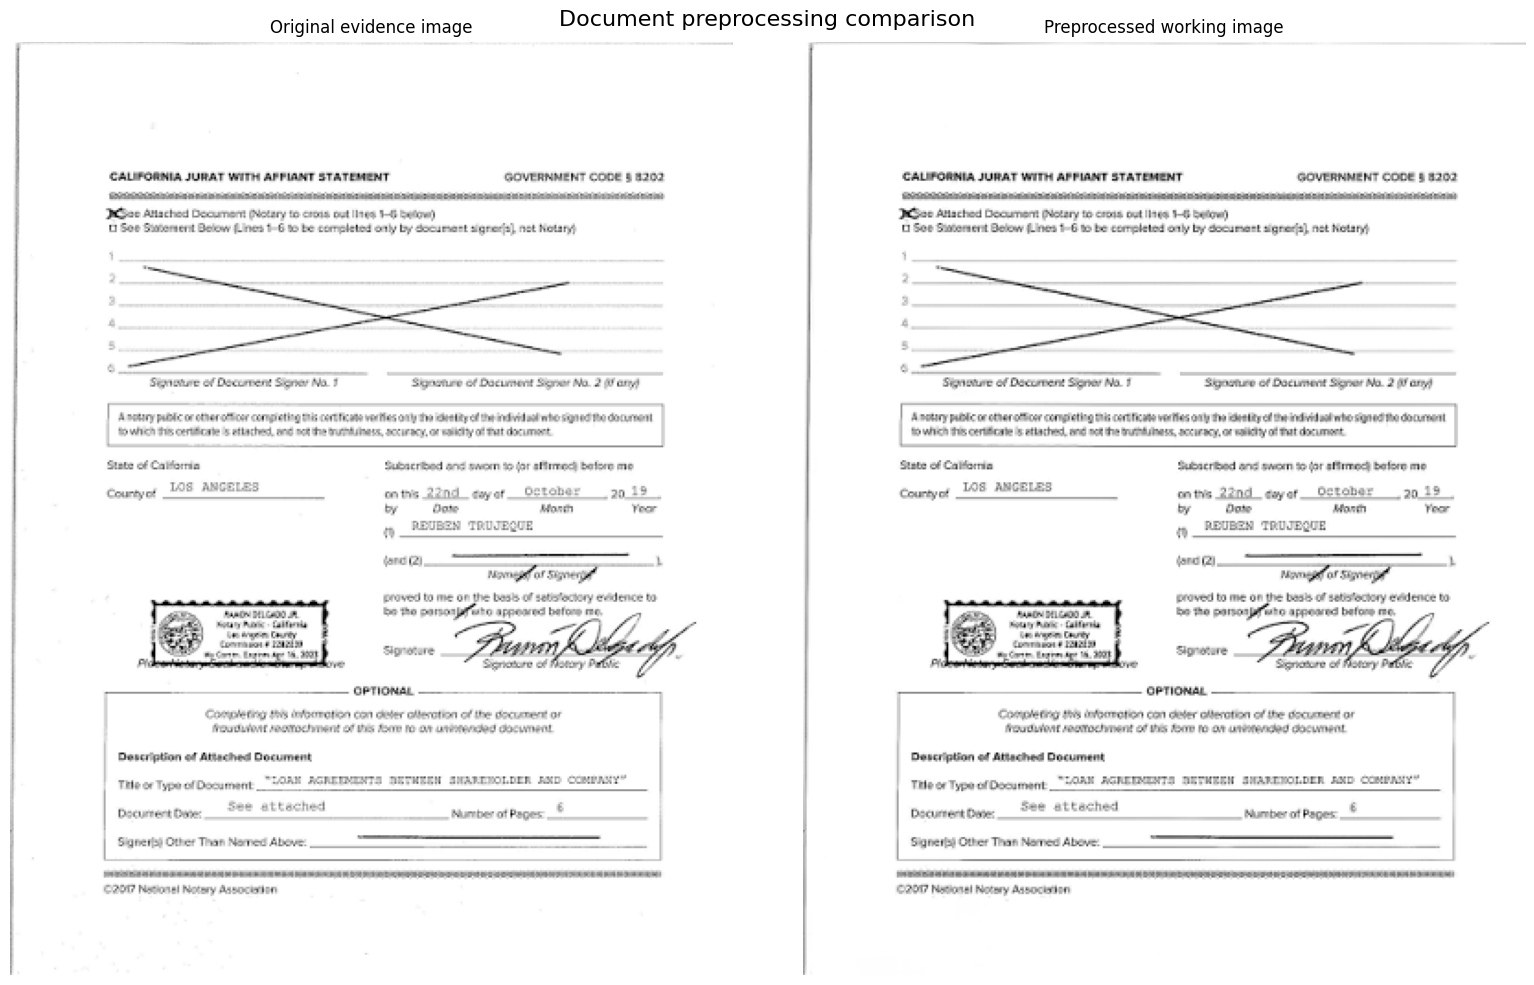

In [20]:
 ## Cell 10 — Display original and preprocessed pages


# %%
import matplotlib.pyplot as plt


figure, axes = plt.subplots(
    1,
    2,
    figsize=(16, 10),
)

axes[0].imshow(
    document_result["original_image"]
)
axes[0].set_title(
    "Original evidence image"
)

axes[1].imshow(
    document_result["preprocessed_image"]
)
axes[1].set_title(
    "Preprocessed working image"
)

for axis in axes:
    axis.axis("off")

figure.suptitle(
    "Document preprocessing comparison",
    fontsize=16,
)
figure.tight_layout()
plt.show()

In [21]:
# ## Cell 11 — Display document-quality checks


# %%
quality = document_result["quality"]

print("DOCUMENT QUALITY SUMMARY")
print("========================")
print("Passed:", quality["passed"])
print("Quality score:", quality["quality_score"])

print("\nMEASUREMENTS")
print("============")
for name, value in quality["measurements"].items():
    print(f"{name}: {value}")

print("\nINDIVIDUAL CHECKS")
print("=================")
for check in quality["checks"]:
    status = "PASS" if check["passed"] else "WARNING"
    print(
        f"[{status}] {check['name']}: "
        f"{check['message']}"
    )

if quality["warnings"]:
    print("\nWARNINGS")
    print("========")
    for warning in quality["warnings"]:
        print("-", warning)
else:
    print("\nNo document-quality warnings.")

DOCUMENT QUALITY SUMMARY
Passed: False
Quality score: 0.833

MEASUREMENTS
width: 393
height: 508
mean_brightness: 243.99
blur_variance: 5013.69
estimated_skew_degrees: 0.0

INDIVIDUAL CHECKS
[PASS] valid_dimensions: Page dimensions are 393 × 508 pixels.
[WARNING] resolution_adequate: Page resolution is below 600 × 600 pixels.
[PASS] not_too_dark: Mean brightness 244.0 is above the dark-page limit.
[PASS] not_too_bright: Mean brightness 244.0 is below the bright-page limit.
[PASS] acceptable_blur: Sharpness measure 5013.7 meets the prototype limit.
[PASS] acceptable_skew: Estimated skew 0.00° is within the correction range.

WARNINGS
- Page resolution is below 600 × 600 pixels.


In [22]:
# ## Cell 12 — Save Stage 1 outputs to Google Drive
#
# A unique UTC run ID prevents one test from overwriting another.


# %%
from datetime import datetime, timezone
import json


RUN_ID = datetime.now(
    timezone.utc
).strftime(
    "%Y%m%dT%H%M%S_%fZ"
)

RUN_DIRECTORY = (
    PROJECT_DIRECTORY
    / "outputs"
    / RUN_ID
)

RUN_DIRECTORY.mkdir(
    parents=True,
    exist_ok=False,
)

original_output_path = (
    RUN_DIRECTORY
    / "01_original_page.png"
)

preprocessed_output_path = (
    RUN_DIRECTORY
    / "02_preprocessed_page.png"
)

comparison_output_path = (
    RUN_DIRECTORY
    / "original_vs_preprocessed.png"
)

quality_output_path = (
    RUN_DIRECTORY
    / "document_quality.json"
)

original_bgr = cv2.cvtColor(
    document_result["original_image"],
    cv2.COLOR_RGB2BGR,
)

preprocessed_bgr = cv2.cvtColor(
    document_result["preprocessed_image"],
    cv2.COLOR_RGB2BGR,
)

if not cv2.imwrite(
    str(original_output_path),
    original_bgr,
):
    raise OSError(
        f"Could not save {original_output_path}"
    )

if not cv2.imwrite(
    str(preprocessed_output_path),
    preprocessed_bgr,
):
    raise OSError(
        f"Could not save {preprocessed_output_path}"
    )

comparison_figure, comparison_axes = plt.subplots(
    1,
    2,
    figsize=(16, 10),
)

comparison_axes[0].imshow(
    document_result["original_image"]
)
comparison_axes[0].set_title(
    "Original evidence image"
)

comparison_axes[1].imshow(
    document_result["preprocessed_image"]
)
comparison_axes[1].set_title(
    "Preprocessed working image"
)

for axis in comparison_axes:
    axis.axis("off")

comparison_figure.tight_layout()
comparison_figure.savefig(
    comparison_output_path,
    dpi=150,
    bbox_inches="tight",
)
plt.close(comparison_figure)

quality_output_path.write_text(
    json.dumps(
        quality,
        indent=2,
    ),
    encoding="utf-8",
)

print("Stage 1 completed successfully.")
print("Run ID:", RUN_ID)
print("Output directory:", RUN_DIRECTORY)
print("\nSaved files:")
print("-", original_output_path.name)
print("-", preprocessed_output_path.name)
print("-", comparison_output_path.name)
print("-", quality_output_path.name)

Stage 1 completed successfully.
Run ID: 20260727T153721_774776Z
Output directory: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z

Saved files:
- 01_original_page.png
- 02_preprocessed_page.png
- original_vs_preprocessed.png
- document_quality.json


In [23]:
%pip install -q "ultralytics>=8.3,<9"

In [24]:
# ## Cell 14 — Add detection settings to config.yaml
#
# This updates only the detection section and preserves the existing document
# settings.


# %%
with CONFIG_PATH.open("r", encoding="utf-8") as config_file:
    current_config = yaml.safe_load(config_file)

current_config["detection"] = {
    # This must eventually point to a trained signature checkpoint.
    "model_path": "models/yolo_signature_detector.pt",
    "base_model": "yolo11n.pt",
    "class_names": {
        0: "signature",
    },
    "confidence_threshold": 0.25,
    "iou_threshold": 0.50,
    "image_size": 1280,
    "minimum_box_area_ratio": 0.0005,
    "maximum_box_area_ratio": 0.35,
    "boundary_margin_pixels": 3,
}

with CONFIG_PATH.open("w", encoding="utf-8") as config_file:
    yaml.safe_dump(
        current_config,
        config_file,
        sort_keys=False,
    )

print("Detection configuration added:", CONFIG_PATH)
print(yaml.safe_dump(current_config["detection"], sort_keys=False))


Detection configuration added: /content/drive/MyDrive/Signature-Forensic-Prototype/config.yaml
model_path: models/yolo_signature_detector.pt
base_model: yolo11n.pt
class_names:
  0: signature
confidence_threshold: 0.25
iou_threshold: 0.5
image_size: 1280
minimum_box_area_ratio: 0.0005
maximum_box_area_ratio: 0.35
boundary_margin_pixels: 3



In [25]:
# ## Cell 15 — Verify and import `detection.py`
#
# Copy the current repository's `src/detection.py` into the Drive project's
# `src` folder before running this cell.


# %%
DETECTION_MODULE_PATH = PROJECT_DIRECTORY / "src/detection.py"

if not DETECTION_MODULE_PATH.is_file():
    raise FileNotFoundError(
        "src/detection.py is missing from the Google Drive project."
    )

import src.detection

importlib.reload(src.detection)

from src.detection import (
    detect_signatures,
    draw_detections,
    load_detection_config,
    load_yolo_model,
    save_detection_outputs,
    summarize_detections,
    xyxy_to_yolo,
)

print("detection.py location:", DETECTION_MODULE_PATH)
print("Detection module imported successfully.")


detection.py location: /content/drive/MyDrive/Signature-Forensic-Prototype/src/detection.py
Detection module imported successfully.


In [26]:
# ## Cell 16 — Demonstrate YOLO annotation conversion
#
# This cell can run before model training. It converts an example pixel box to
# the normalized YOLO training-label format.


# %%
example_label = xyxy_to_yolo(
    bbox_xyxy=[100, 500, 700, 750],
    image_width=1000,
    image_height=1400,
    class_id=0,
)

print("YOLO label:")
print(example_label)
print("\nFormat: class_id x_center y_center width height")


YOLO label:
0 0.400000 0.446429 0.600000 0.178571

Format: class_id x_center y_center width height


In [27]:
# ## Cell 17 — Select the trained signature checkpoint
#
# Do not use the standard COCO `yolo11n.pt` model for signature inference. COCO
# YOLO models do not contain a signature class. Upload or train a compatible
# checkpoint and store it at the path below.


# %%
YOLO_CHECKPOINT_PATH = (
    PROJECT_DIRECTORY
    / "models/yolo_signature_detector.pt"
)

if not YOLO_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        "A trained signature detector is required before inference. "
        f"Expected checkpoint: {YOLO_CHECKPOINT_PATH}"
    )

detection_config = load_detection_config(
    CONFIG_PATH
)

yolo_model = load_yolo_model(
    YOLO_CHECKPOINT_PATH,
    require_signature_class=True,
)

print("Signature detector loaded:", YOLO_CHECKPOINT_PATH)
print("Model classes:", yolo_model.names)

Signature detector loaded: /content/drive/MyDrive/Signature-Forensic-Prototype/models/yolo_signature_detector.pt
Model classes: {0: 'signature'}


In [28]:
%pip install -q \
    huggingface_hub \
    ultralytics

In [29]:
from huggingface_hub import notebook_login

notebook_login()

In [30]:
from huggingface_hub import hf_hub_download
from pathlib import Path
import shutil

# Define PROJECT_DIRECTORY if it's not already in scope (e.g., if previous cells were not run)
PROJECT_DIRECTORY = Path(
    "/content/drive/MyDrive/Signature-Forensic-Prototype"
)


downloaded_model_path = hf_hub_download(
    repo_id=(
        "tech4humans/"
        "yolov8s-signature-detector"
    ),
    filename="yolov8s.pt",
)


YOLO_CHECKPOINT_PATH = (
    PROJECT_DIRECTORY
    / "models/yolo_signature_detector.pt"
)


shutil.copy2(
    downloaded_model_path,
    YOLO_CHECKPOINT_PATH,
)


print(
    "Signature model saved:",
    YOLO_CHECKPOINT_PATH,
)

print(
    "Checkpoint exists:",
    YOLO_CHECKPOINT_PATH.is_file(),
)

print(
    "Checkpoint size:",
    YOLO_CHECKPOINT_PATH.stat().st_size,
    "bytes",
)

Signature model saved: /content/drive/MyDrive/Signature-Forensic-Prototype/models/yolo_signature_detector.pt
Checkpoint exists: True
Checkpoint size: 22515427 bytes


In [31]:
from ultralytics import YOLO

tech4humans_model = YOLO(
    str(YOLO_CHECKPOINT_PATH)
)

print(
    "Model classes:",
    tech4humans_model.names,
)

Model classes: {0: 'signature'}


In [32]:
# ## Cell 18 — Run detection on the preprocessed page


# %%
detection_results = detect_signatures(
    page_image=document_result["preprocessed_image"],
    model=yolo_model,
    detection_config=detection_config,
    device=0 if torch.cuda.is_available() else "cpu",
)

detection_summary = summarize_detections(
    detection_results
)
print("Detection summary:", detection_summary)

for index, detection in enumerate(
    detection_results,
    start=1,
):
    print(f"\nDetection {index}")
    print("  Class:", detection["class_name"])
    print("  Confidence:", detection["confidence"])
    print("  Box:", detection["bbox_xyxy"])
    print("  Crop shape:", detection["crop"].shape)
    print("  Quality:", detection["quality"])

Detection summary: {'signature_detected': True, 'detection_count': 4, 'passed': True, 'warnings': ['Multiple possible signatures were detected: 4']}

Detection 1
  Class: signature
  Confidence: 0.717405
  Box: [237, 308, 373, 348]
  Crop shape: (40, 136, 3)
  Quality: {'passed': True, 'box_area_ratio': 0.027249, 'touches_boundary': False, 'warnings': []}

Detection 2
  Class: signature
  Confidence: 0.35772
  Box: [273, 284, 321, 298]
  Crop shape: (14, 48, 3)
  Quality: {'passed': True, 'box_area_ratio': 0.003366, 'touches_boundary': False, 'warnings': []}

Detection 3
  Class: signature
  Confidence: 0.281271
  Box: [141, 129, 303, 170]
  Crop shape: (41, 162, 3)
  Quality: {'passed': True, 'box_area_ratio': 0.033269, 'touches_boundary': False, 'warnings': []}

Detection 4
  Class: signature
  Confidence: 0.273598
  Box: [56, 144, 195, 187]
  Crop shape: (43, 139, 3)
  Quality: {'passed': True, 'box_area_ratio': 0.029938, 'touches_boundary': False, 'warnings': []}


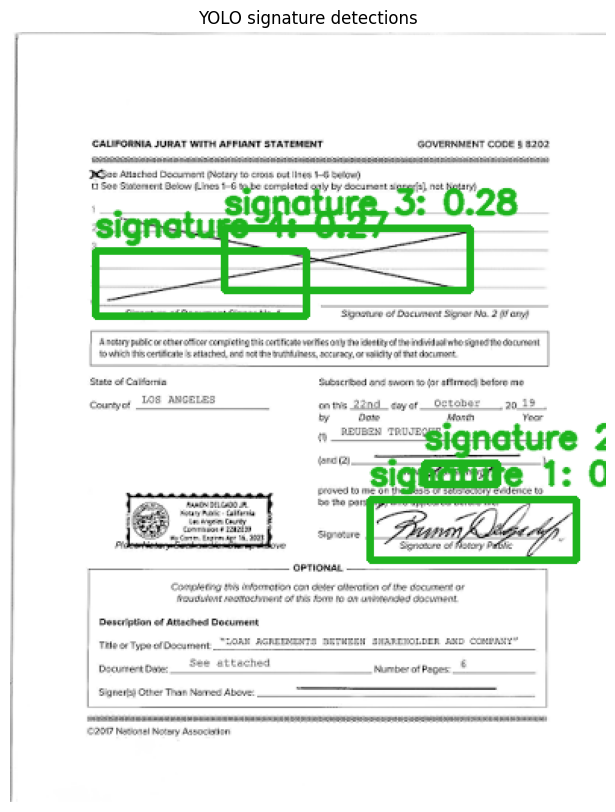

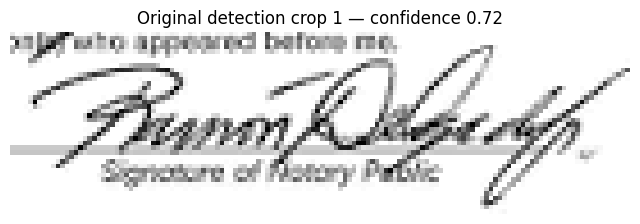

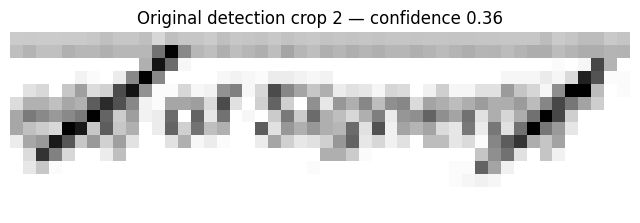

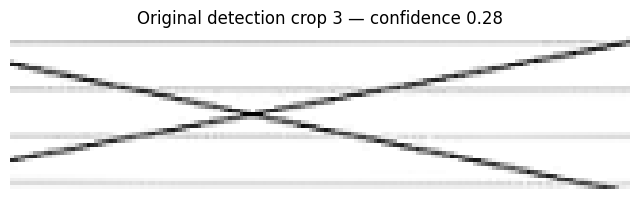

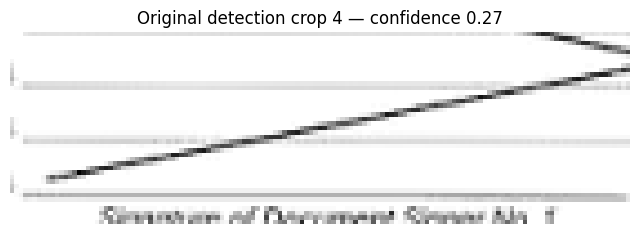

In [33]:
# ## Cell 19 — Display YOLO detections and unchanged crops


# %%
detection_visualization = draw_detections(
    document_result["preprocessed_image"],
    detection_results,
)

plt.figure(figsize=(12, 10))
plt.imshow(detection_visualization)
plt.title("YOLO signature detections")
plt.axis("off")
plt.show()

for index, detection in enumerate(
    detection_results,
    start=1,
):
    plt.figure(figsize=(8, 3))
    plt.imshow(detection["crop"])
    plt.title(
        f"Original detection crop {index} — "
        f"confidence {detection['confidence']:.2f}"
    )
    plt.axis("off")
    plt.show()

In [34]:
# ## Cell 20 — Save Stage 2 outputs


# %%
detection_output_paths = save_detection_outputs(
    detections=detection_results,
    visualization=detection_visualization,
    output_directory=RUN_DIRECTORY,
)

print("Stage 2 completed.")
print("Detection summary:", detection_summary)
print("Saved outputs:", detection_output_paths)

Stage 2 completed.
Detection summary: {'signature_detected': True, 'detection_count': 4, 'passed': True, 'warnings': ['Multiple possible signatures were detected: 4']}
Saved outputs: {'visualization_path': '/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/03_yolo_detection.png', 'crop_paths': ['/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/04_original_signature_crop_01.png', '/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/04_original_signature_crop_02.png', '/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/04_original_signature_crop_03.png', '/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/04_original_signature_crop_04.png'], 'metadata_path': '/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/detection_metadata.json'}


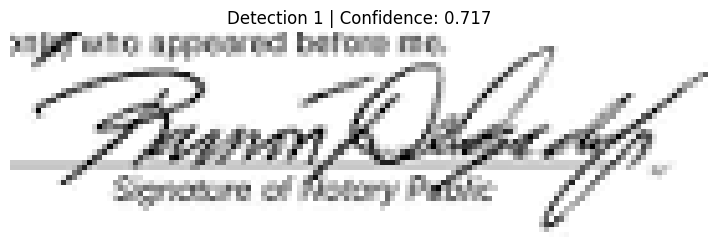

Detection 1: [237, 308, 373, 348]


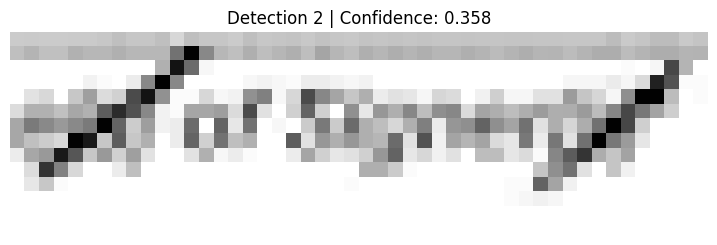

Detection 2: [273, 284, 321, 298]


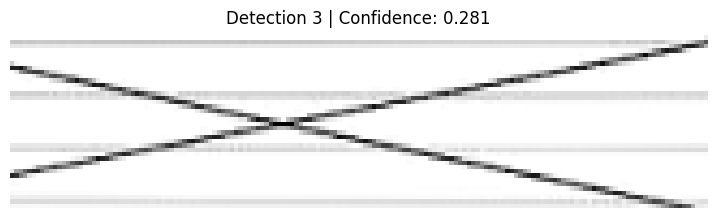

Detection 3: [141, 129, 303, 170]


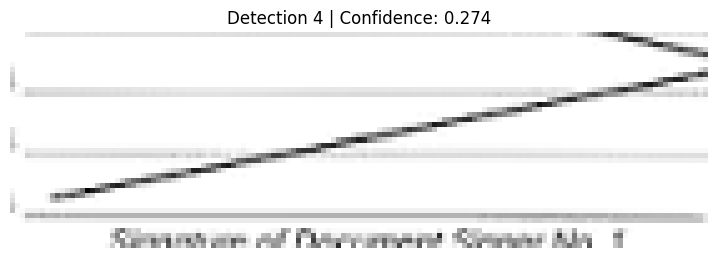

Detection 4: [56, 144, 195, 187]


In [36]:
for detection_number, detection in enumerate(
    detection_results,
    start=1,
):
    plt.figure(figsize=(9, 3))

    plt.imshow(
        detection["crop"]
    )

    plt.title(
        f"Detection {detection_number} | "
        f"Confidence: "
        f"{detection['confidence']:.3f}"
    )

    plt.axis("off")
    plt.show()

    print(
        f"Detection {detection_number}:",
        detection["bbox_xyxy"],
    )

In [37]:
ACCEPTED_DETECTION_NUMBERS = [1]

In [38]:
accepted_detections = []
rejected_detections = []

for detection_number, detection in enumerate(
    detection_results,
    start=1,
):
    reviewed_detection = detection.copy()

    reviewed_detection["human_review"] = {
        "accepted": (
            detection_number
            in ACCEPTED_DETECTION_NUMBERS
        ),
        "detection_number": detection_number,
    }

    if (
        detection_number
        in ACCEPTED_DETECTION_NUMBERS
    ):
        accepted_detections.append(
            reviewed_detection
        )
    else:
        rejected_detections.append(
            reviewed_detection
        )


print(
    "Accepted signatures:",
    len(accepted_detections),
)

print(
    "Rejected detections:",
    len(rejected_detections),
)

Accepted signatures: 1
Rejected detections: 3


In [39]:
%%writefile /content/drive/MyDrive/Signature-Forensic-Prototype/src/segmentation.py

Writing /content/drive/MyDrive/Signature-Forensic-Prototype/src/segmentation.py


In [40]:
%pip install -q "transformers>=4.45,<6" "safetensors>=0.4,<1"

In [41]:
# ## Cell 22 — Add segmentation settings to config.yaml
#
# These are prototype quality limits. They must be evaluated on representative
# validation documents before consequential use.


# %%
with CONFIG_PATH.open("r", encoding="utf-8") as config_file:
    current_config = yaml.safe_load(config_file)

current_config["segmentation"] = {
    "model_name": "facebook/sam-vit-base",
    "minimum_mask_area_ratio": 0.01,
    "maximum_mask_area_ratio": 0.70,
    "maximum_boundary_contact_ratio": 0.50,
    "minimum_ink_agreement": 0.25,
    "rectangularity_warning_threshold": 0.90,
}

with CONFIG_PATH.open("w", encoding="utf-8") as config_file:
    yaml.safe_dump(
        current_config,
        config_file,
        sort_keys=False,
    )

print("Segmentation configuration added:", CONFIG_PATH)
print(
    yaml.safe_dump(
        current_config["segmentation"],
        sort_keys=False,
    )
)

Segmentation configuration added: /content/drive/MyDrive/Signature-Forensic-Prototype/config.yaml
model_name: facebook/sam-vit-base
minimum_mask_area_ratio: 0.01
maximum_mask_area_ratio: 0.7
maximum_boundary_contact_ratio: 0.5
minimum_ink_agreement: 0.25
rectangularity_warning_threshold: 0.9



In [42]:
# ## Cell 23 — Verify and import `segmentation.py`
#
# Copy the repository's current `src/segmentation.py` into the Drive project's
# `src` directory before running this cell.


# %%
SEGMENTATION_MODULE_PATH = (
    PROJECT_DIRECTORY
    / "src/segmentation.py"
)

if not SEGMENTATION_MODULE_PATH.is_file():
    raise FileNotFoundError(
        "src/segmentation.py is missing from the Google Drive project."
    )

import src.segmentation

importlib.reload(src.segmentation)

from src.segmentation import (
    create_mask_overlay,
    load_sam_model,
    load_segmentation_config,
    save_segmentation_outputs,
    segment_accepted_detections,
)

print("segmentation.py location:", SEGMENTATION_MODULE_PATH)
print("Segmentation module imported successfully.")

segmentation.py location: /content/drive/MyDrive/Signature-Forensic-Prototype/src/segmentation.py
Segmentation module imported successfully.


In [43]:
# ## Cell 24 — Load SAM
#
# The first run downloads the pretrained SAM base checkpoint. Google Drive
# stores our outputs, while Hugging Face may cache the downloaded model in the
# temporary Colab runtime.


# %%
segmentation_config = load_segmentation_config(
    CONFIG_PATH
)

sam_model, sam_processor = load_sam_model(
    model_name=segmentation_config["model_name"],
    device=DEVICE,
)

print("SAM model loaded:", segmentation_config["model_name"])
print("SAM device:", DEVICE)

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/6.57k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  375MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

SAM model loaded: facebook/sam-vit-base
SAM device: cuda


In [44]:
# ## Cell 25 — Segment the accepted signature box


# %%
segmentation_results = segment_accepted_detections(
    page_image=document_result["preprocessed_image"],
    accepted_detections=accepted_detections,
    model=sam_model,
    processor=sam_processor,
    segmentation_config=segmentation_config,
    device=DEVICE,
)

print("Segmentation results:", len(segmentation_results))

for index, segmentation_result in enumerate(
    segmentation_results,
    start=1,
):
    print(f"\nSegmentation {index}")
    print("  Box:", segmentation_result["bbox_xyxy"])
    print(
        "  Mask area ratio:",
        segmentation_result["mask_area_ratio"],
    )
    print(
        "  Touches boundary:",
        segmentation_result["touches_boundary"],
    )
    print(
        "  Quality:",
        segmentation_result["quality"],
    )

Segmentation results: 1

Segmentation 1
  Box: [237, 308, 373, 348]
  Mask area ratio: 0.415993
  Touches boundary: True
  Quality: {'passed': True, 'quality_score': 1.0, 'sam_predicted_iou': 0.909115, 'mask_area_ratio': 0.415993, 'ink_agreement': 0.358859, 'boundary_sides_touched': 1, 'rectangularity': 0.493566, 'warnings': []}


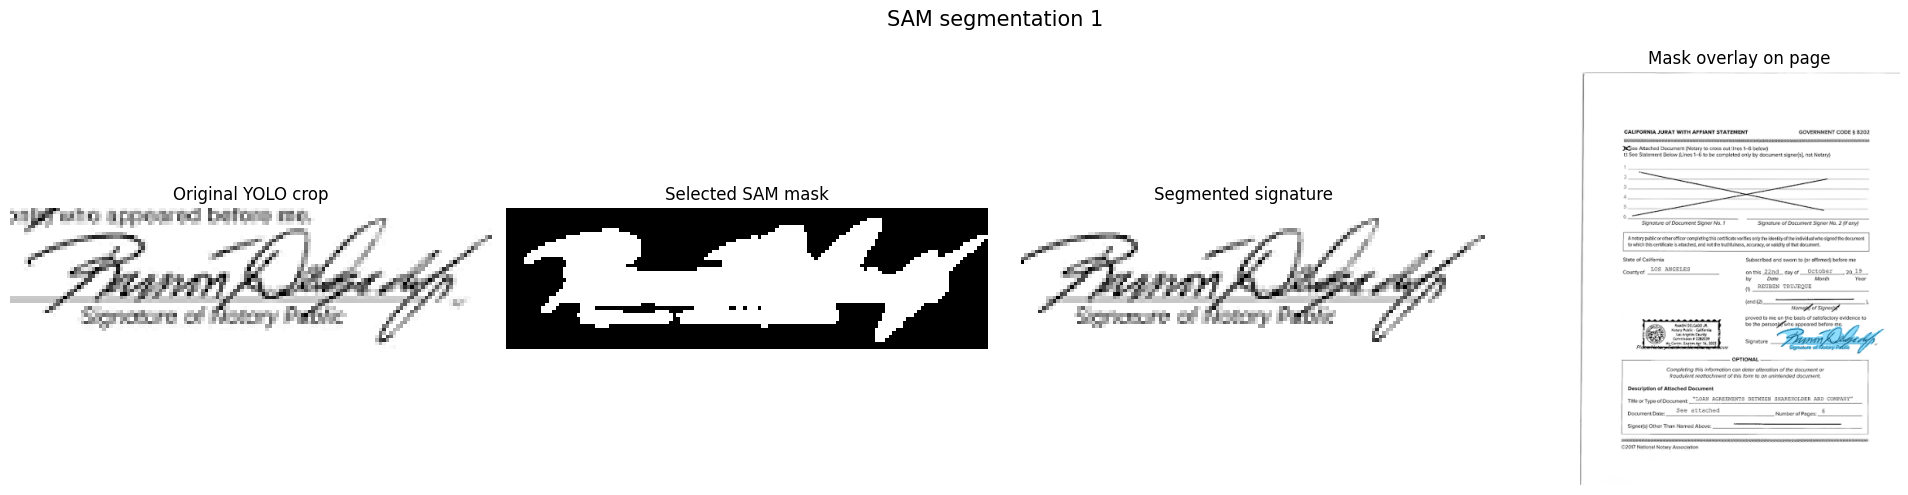

In [45]:
# ## Cell 26 — Display the SAM result
#
# Inspect all four panels. A good result should preserve signature strokes
# without selecting the entire rectangular crop or mostly selecting background.


# %%
for index, segmentation_result in enumerate(
    segmentation_results,
    start=1,
):
    mask_overlay = create_mask_overlay(
        document_result["preprocessed_image"],
        segmentation_result["full_page_mask"],
    )

    figure, axes = plt.subplots(
        1,
        4,
        figsize=(20, 5),
    )

    axes[0].imshow(
        segmentation_result["original_crop"]
    )
    axes[0].set_title("Original YOLO crop")

    axes[1].imshow(
        segmentation_result["mask"],
        cmap="gray",
    )
    axes[1].set_title("Selected SAM mask")

    axes[2].imshow(
        segmentation_result["segmented_signature"]
    )
    axes[2].set_title("Segmented signature")

    axes[3].imshow(mask_overlay)
    axes[3].set_title("Mask overlay on page")

    for axis in axes:
        axis.axis("off")

    figure.suptitle(
        f"SAM segmentation {index}",
        fontsize=15,
    )
    figure.tight_layout()
    plt.show()


In [46]:
# ## Cell 27 — Save Stage 3 outputs


# %%
segmentation_output_paths = save_segmentation_outputs(
    segmentation_results=segmentation_results,
    page_image=document_result["preprocessed_image"],
    output_directory=RUN_DIRECTORY,
)

print("Stage 3 completed.")
print("Saved segmentation outputs:")

for saved_output in segmentation_output_paths:
    print(saved_output)


Stage 3 completed.
Saved segmentation outputs:
{'overlay_path': '/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/05_sam_mask_overlay.png', 'mask_path': '/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/05_sam_mask.png', 'segmented_signature_path': '/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/06_segmented_signature.png', 'quality_path': '/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/segmentation_quality.json'}


In [47]:
%%writefile /content/drive/MyDrive/Signature-Forensic-Prototype/src/cleaning.py

Writing /content/drive/MyDrive/Signature-Forensic-Prototype/src/cleaning.py


In [55]:
import importlib
import src.cleaning

importlib.reload(src.cleaning)

from src.cleaning import (
    clean_segmentation_results,
    load_cleaning_config,
    save_cleaning_outputs,
)

In [48]:
# OpenCV handles thresholding, line detection, components, and morphology.
# Scikit-image supplies a clear and well-tested skeletonization function.

#
%pip install -q "scikit-image>=0.22,<1"

In [49]:
# ## Cell 29 — Add cleaning settings to config.yaml


# %%
with CONFIG_PATH.open("r", encoding="utf-8") as config_file:
    current_config = yaml.safe_load(config_file)

current_config["cleaning"] = {
    "adaptive_threshold_block_size": 31,
    "adaptive_threshold_constant": 11,
    "minimum_component_area": 4,
    "maximum_component_area_ratio": 0.80,
    "line_detection_threshold": 50,
    "minimum_line_length": 30,
    "maximum_line_gap": 8,
    "line_removal_width": 1,
    "closing_kernel_size": 2,
    "maximum_foreground_removal_ratio": 0.35,
    "maximum_endpoint_change_ratio": 0.50,
    "canvas_width": 384,
    "canvas_height": 192,
    "canvas_padding": 12,
}

with CONFIG_PATH.open("w", encoding="utf-8") as config_file:
    yaml.safe_dump(
        current_config,
        config_file,
        sort_keys=False,
    )

print("Cleaning configuration added:", CONFIG_PATH)
print(
    yaml.safe_dump(
        current_config["cleaning"],
        sort_keys=False,
    )
)

Cleaning configuration added: /content/drive/MyDrive/Signature-Forensic-Prototype/config.yaml
adaptive_threshold_block_size: 31
adaptive_threshold_constant: 11
minimum_component_area: 4
maximum_component_area_ratio: 0.8
line_detection_threshold: 50
minimum_line_length: 30
maximum_line_gap: 8
line_removal_width: 1
closing_kernel_size: 2
maximum_foreground_removal_ratio: 0.35
maximum_endpoint_change_ratio: 0.5
canvas_width: 384
canvas_height: 192
canvas_padding: 12



In [50]:
## Cell 30 — Verify and import `cleaning.py`
#
# Copy the repository's current `src/cleaning.py` into the Drive project's
# `src` directory before running this cell.


# %%
CLEANING_MODULE_PATH = (
    PROJECT_DIRECTORY
    / "src/cleaning.py"
)

if not CLEANING_MODULE_PATH.is_file():
    raise FileNotFoundError(
        "src/cleaning.py is missing from the Google Drive project."
    )

import src.cleaning

importlib.reload(src.cleaning)

from src.cleaning import (
    clean_segmentation_results,
    load_cleaning_config,
    save_cleaning_outputs,
)

print("cleaning.py location:", CLEANING_MODULE_PATH)
print("Cleaning module imported successfully.")

cleaning.py location: /content/drive/MyDrive/Signature-Forensic-Prototype/src/cleaning.py
Cleaning module imported successfully.


In [56]:
# ## Cell 31 — Run conservative cleaning


# %%
cleaning_config = load_cleaning_config(
    CONFIG_PATH
)

cleaning_results = clean_segmentation_results(
    segmentation_results=segmentation_results,
    cleaning_config=cleaning_config,
)

print("Cleaning results:", len(cleaning_results))

for index, cleaning_result in enumerate(
    cleaning_results,
    start=1,
):
    print(f"\nCleaning result {index}")
    print(
        "  Connected components:",
        cleaning_result["connected_components"],
    )
    print(
        "  Quality:",
        cleaning_result["quality"],
    )

Cleaning results: 1

Cleaning result 1
  Connected components: 5
  Quality: {'passed': False, 'quality_score': 1.0, 'foreground_removal_ratio': 0.0, 'original_components': 5, 'cleaned_components': 5, 'original_endpoints': 26, 'cleaned_endpoints': 26, 'endpoint_change_ratio': 0.0, 'fallback_used': True, 'fallback_reason': 'proposed cleaning would remove 40.9% of foreground, above the 35.0% limit', 'warnings': ['Conservative fallback used: proposed cleaning would remove 40.9% of foreground, above the 35.0% limit. The original SAM-derived ink was preserved.']}


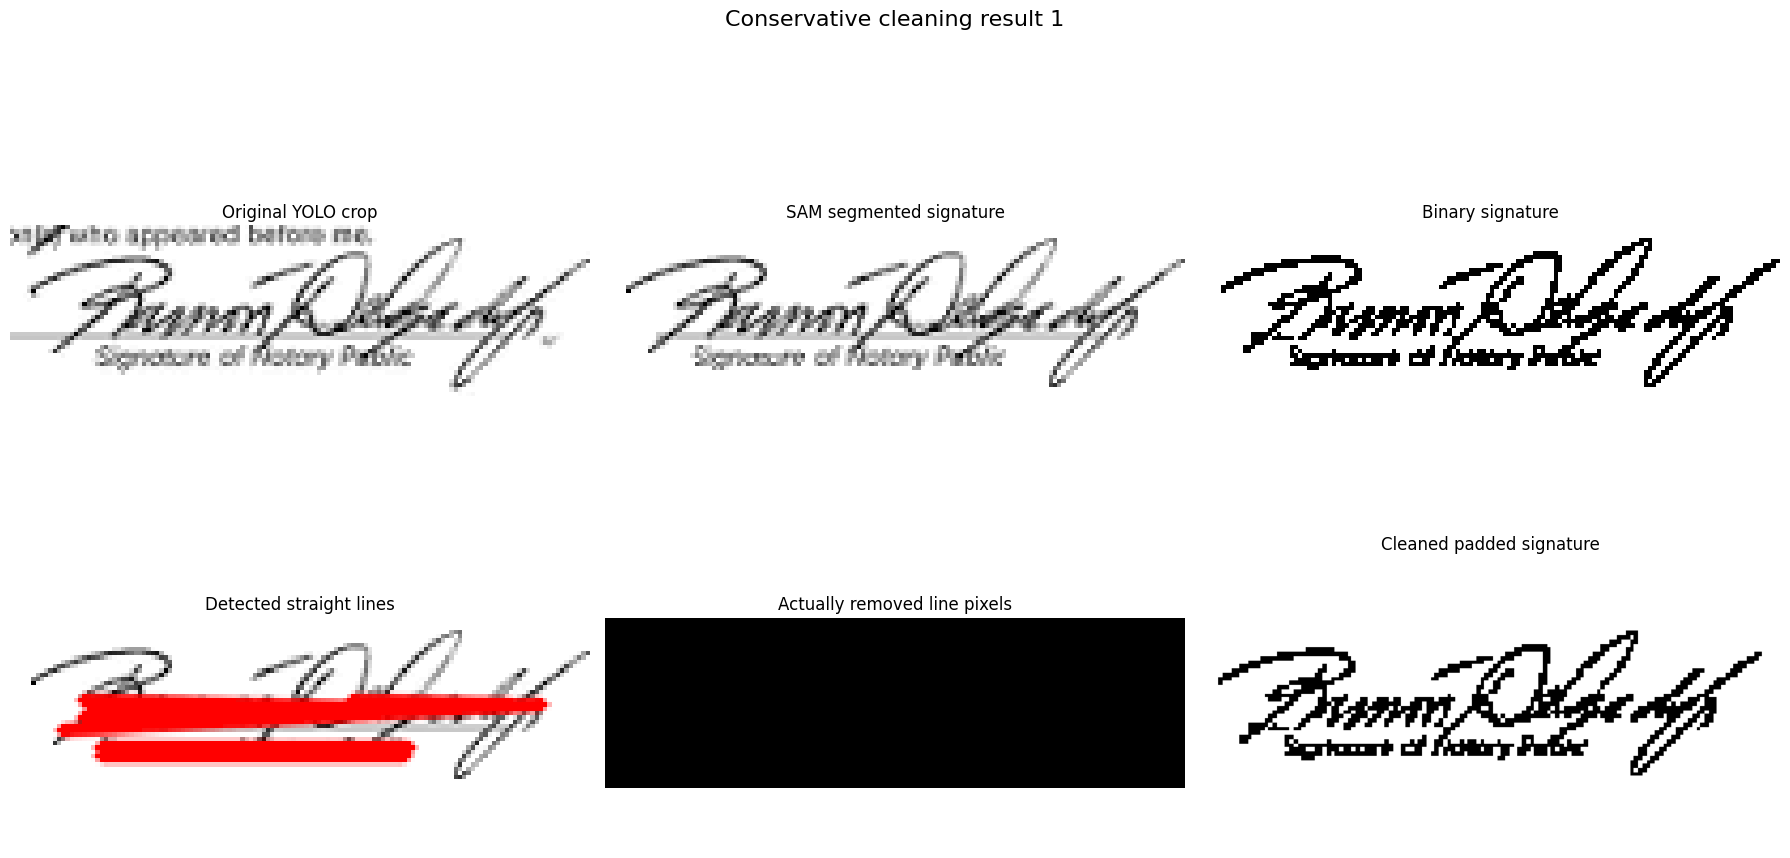

In [57]:
# ## Cell 32 — Display every cleaning stage
#
# Red lines show what the Hough transform identified as long straight
# interference. White pixels in the removed-line mask show pixels actually
# removed. If line removal would erase too much foreground, the module rolls
# back that removal automatically.


# %%
for index, cleaning_result in enumerate(
    cleaning_results,
    start=1,
):
    figure, axes = plt.subplots(
        2,
        3,
        figsize=(18, 10),
    )

    axes[0, 0].imshow(
        cleaning_result["original_crop"]
    )
    axes[0, 0].set_title("Original YOLO crop")

    axes[0, 1].imshow(
        cleaning_result["sam_segmented_signature"]
    )
    axes[0, 1].set_title("SAM segmented signature")

    axes[0, 2].imshow(
        cleaning_result["binary_signature"],
        cmap="gray",
    )
    axes[0, 2].set_title("Binary signature")

    axes[1, 0].imshow(
        cleaning_result["detected_lines_image"]
    )
    axes[1, 0].set_title("Detected straight lines")

    axes[1, 1].imshow(
        cleaning_result["removed_line_mask"],
        cmap="gray",
    )
    axes[1, 1].set_title("Actually removed line pixels")

    axes[1, 2].imshow(
        cleaning_result["cleaned_signature"]
    )
    axes[1, 2].set_title("Cleaned padded signature")

    for axis in axes.flat:
        axis.axis("off")

    figure.suptitle(
        f"Conservative cleaning result {index}",
        fontsize=16,
    )
    figure.tight_layout()
    plt.show()


In [58]:
# ## Cell 33 — Review cleaning quality


# %%
for index, cleaning_result in enumerate(
    cleaning_results,
    start=1,
):
    quality = cleaning_result["quality"]

    print(f"CLEANING QUALITY {index}")
    print("=" * 30)
    print("Passed:", quality["passed"])
    print("Quality score:", quality["quality_score"])
    print(
        "Foreground removal ratio:",
        quality["foreground_removal_ratio"],
    )
    print(
        "Components:",
        quality["original_components"],
        "before →",
        quality["cleaned_components"],
        "after",
    )
    print(
        "Skeleton endpoints:",
        quality["original_endpoints"],
        "before →",
        quality["cleaned_endpoints"],
        "after",
    )
    print(
        "Endpoint change ratio:",
        quality["endpoint_change_ratio"],
    )

    if quality["warnings"]:
        print("Warnings:")
        for warning in quality["warnings"]:
            print("-", warning)
    else:
        print("No cleaning-quality warnings.")

    print()

CLEANING QUALITY 1
Passed: False
Quality score: 1.0
Foreground removal ratio: 0.0
Components: 5 before → 5 after
Skeleton endpoints: 26 before → 26 after
Endpoint change ratio: 0.0
Warnings:
- Conservative fallback used: proposed cleaning would remove 40.9% of foreground, above the 35.0% limit. The original SAM-derived ink was preserved.



In [59]:
# ## Cell 34 — Save Stage 4 outputs


# %%
cleaning_output_paths = save_cleaning_outputs(
    cleaning_results=cleaning_results,
    output_directory=RUN_DIRECTORY,
)

print("Stage 4 completed.")
print("Saved cleaning outputs:")

for saved_output in cleaning_output_paths:
    print(saved_output)

Stage 4 completed.
Saved cleaning outputs:
{'detected_lines_path': '/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/07_detected_lines.png', 'binary_signature_path': '/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/07_binary_signature.png', 'removed_line_mask_path': '/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/07_removed_line_mask.png', 'cleaned_signature_path': '/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/08_cleaned_signature.png', 'quality_path': '/content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/cleaning_quality.json'}


In [60]:
# Stage 5 — Siamese ResNet-18 verification will compare the cleaned questioned
# signature with three to five genuine reference signatures. Its training data
# and model calibration are separate from YOLO detection training.


# %% [markdown]
# # Stage 5 — ResNet-18 Siamese verification
#
# The two Siamese branches share exactly the same ResNet-18 encoder. Training
# uses BHSig260 genuine/genuine pairs as positives and both skilled-forgery and
# different-writer pairs as negatives.
#
# Similarity is supporting evidence only. It does not prove authenticity.

In [62]:
%%writefile /content/drive/MyDrive/Signature-Forensic-Prototype/src/verification.py

Writing /content/drive/MyDrive/Signature-Forensic-Prototype/src/verification.py


In [63]:
# ## Cell 35 — Install verification dependencies

#
%pip install -q "scikit-learn>=1.4,<2" "torchvision>=0.17,<1"

In [65]:
# ## Cell 36 — Place BHSig260 in Google Drive
#
# Download and extract the authorized BHSig260 dataset before continuing. The
# expected folders contain one subfolder per writer.
#
# The Kaggle distribution is approximately 4 GB and also includes CEDAR. Only
# the Bengali and Hindi BHSig260 folders are required here.


# %%
BHSIG_ROOT_DIRECTORY = (
    PROJECT_DIRECTORY
    / "data/BHSig260"
)

BENGALI_DIRECTORY = (
    BHSIG_ROOT_DIRECTORY
    / "BHSig260-Bengali"
)

HINDI_DIRECTORY = (
    BHSIG_ROOT_DIRECTORY
    / "BHSig260-Hindi"
)

print("Expected Bengali directory:", BENGALI_DIRECTORY)
print("Expected Hindi directory:", HINDI_DIRECTORY)
print("Bengali directory exists:", BENGALI_DIRECTORY.is_dir())
print("Hindi directory exists:", HINDI_DIRECTORY.is_dir())

if not BENGALI_DIRECTORY.is_dir():
    raise FileNotFoundError(
        f"Bengali BHSig260 directory not found: {BENGALI_DIRECTORY}"
    )

if not HINDI_DIRECTORY.is_dir():
    raise FileNotFoundError(
        f"Hindi BHSig260 directory not found: {HINDI_DIRECTORY}"
    )


Expected Bengali directory: /content/drive/MyDrive/Signature-Forensic-Prototype/data/BHSig260/BHSig260-Bengali
Expected Hindi directory: /content/drive/MyDrive/Signature-Forensic-Prototype/data/BHSig260/BHSig260-Hindi
Bengali directory exists: True
Hindi directory exists: True


In [66]:
# ## Cell 37 — Add verification settings to config.yaml
#
# Training is intentionally moderate for a Colab demonstration. Increasing
# epochs or pairs increases training time and does not guarantee better
# writer-independent performance.


# %%
with CONFIG_PATH.open("r", encoding="utf-8") as config_file:
    current_config = yaml.safe_load(config_file)

current_config["verification"] = {
    "model_path": "models/siamese_resnet18.pt",
    "calibration_path": "models/verification_calibration.json",
    "writer_split_path": "models/writer_split.json",
    "training_history_path": "models/siamese_training_history.json",
    "embedding_dimension": 256,
    "input_width": 224,
    "input_height": 224,
    "minimum_reference_count": 3,
    "recommended_reference_count": 5,
    "score_spread_warning": 0.20,
    "epochs": 10,
    "batch_size": 32,
    "learning_rate": 0.0001,
    "weight_decay": 0.0001,
    "contrastive_margin": 1.0,
    "data_loader_workers": 2,
    "positive_pairs_per_writer": 40,
    "skilled_negative_pairs_per_writer": 20,
    "random_negative_pairs_per_writer": 20,
    "train_writer_fraction": 0.80,
    "validation_writer_fraction": 0.10,
    "uncertainty_margin": 0.05,
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std": [0.229, 0.224, 0.225],
}

with CONFIG_PATH.open("w", encoding="utf-8") as config_file:
    yaml.safe_dump(
        current_config,
        config_file,
        sort_keys=False,
    )

print("Verification configuration added:", CONFIG_PATH)
print(
    yaml.safe_dump(
        current_config["verification"],
        sort_keys=False,
    )
)

Verification configuration added: /content/drive/MyDrive/Signature-Forensic-Prototype/config.yaml
model_path: models/siamese_resnet18.pt
calibration_path: models/verification_calibration.json
writer_split_path: models/writer_split.json
training_history_path: models/siamese_training_history.json
embedding_dimension: 256
input_width: 224
input_height: 224
minimum_reference_count: 3
recommended_reference_count: 5
epochs: 10
batch_size: 32
learning_rate: 0.0001
weight_decay: 0.0001
contrastive_margin: 1.0
data_loader_workers: 2
positive_pairs_per_writer: 40
skilled_negative_pairs_per_writer: 20
random_negative_pairs_per_writer: 20
train_writer_fraction: 0.8
validation_writer_fraction: 0.1
uncertainty_margin: 0.05
imagenet_mean:
- 0.485
- 0.456
- 0.406
imagenet_std:
- 0.229
- 0.224
- 0.225



In [67]:
# ## Cell 38 — Verify and import `verification.py`
#
# Copy the repository's current `src/verification.py` into the Drive project's
# `src` directory before running this cell.


# %%
VERIFICATION_MODULE_PATH = (
    PROJECT_DIRECTORY
    / "src/verification.py"
)

if not VERIFICATION_MODULE_PATH.is_file():
    raise FileNotFoundError(
        "src/verification.py is missing from the Google Drive project."
    )

import src.verification

importlib.reload(src.verification)

from src.verification import (
    SiameseResNet18,
    calibrate_similarity_thresholds,
    collect_pair_scores,
    compare_with_references,
    create_writer_disjoint_split,
    discover_bhsig260,
    generate_balanced_pairs,
    load_calibration,
    load_siamese_checkpoint,
    load_verification_config,
    save_calibration,
    save_writer_split,
    summarize_writers,
    train_siamese_model,
    validate_reference_signatures,
)

print("verification.py location:", VERIFICATION_MODULE_PATH)
print("Verification module imported successfully.")

verification.py location: /content/drive/MyDrive/Signature-Forensic-Prototype/src/verification.py
Verification module imported successfully.


In [76]:
from pathlib import Path
import shutil
import zipfile

# Change only this filename if your ZIP has a different name.
BHSIG_ZIP_IN_DRIVE = (
    PROJECT_DIRECTORY
    / "data/BHSig260.zip"
)

LOCAL_ZIP_PATH = Path(
    "/content/BHSig260.zip"
)

LOCAL_EXTRACT_DIRECTORY = Path(
    "/content/BHSig260"
)

if not BHSIG_ZIP_IN_DRIVE.is_file():
    raise FileNotFoundError(
        f"Dataset ZIP not found: {BHSIG_ZIP_IN_DRIVE}\n"
        "Upload the ZIP to this location or change BHSIG_ZIP_IN_DRIVE."
    )

zip_size = BHSIG_ZIP_IN_DRIVE.stat().st_size
free_space = shutil.disk_usage("/content").free

# Allow space for both the local ZIP and the extracted files.
if free_space < zip_size * 2:
    raise OSError(
        "The Colab VM may not have enough free disk space. "
        f"ZIP: {zip_size / 1e9:.2f} GB; "
        f"free: {free_space / 1e9:.2f} GB."
    )

# Copy in chunks and print progress. If a complete local copy already exists,
# do not copy it again during the same Colab session.
if (
    not LOCAL_ZIP_PATH.is_file()
    or LOCAL_ZIP_PATH.stat().st_size != zip_size
):
    copied_bytes = 0
    chunk_size = 16 * 1024 * 1024

    with BHSIG_ZIP_IN_DRIVE.open("rb") as source_file:
        with LOCAL_ZIP_PATH.open("wb") as destination_file:
            while True:
                chunk = source_file.read(chunk_size)
                if not chunk:
                    break
                destination_file.write(chunk)
                copied_bytes += len(chunk)
                print(
                    f"\rCopied {copied_bytes / 1e9:.2f} "
                    f"of {zip_size / 1e9:.2f} GB",
                    end="",
                )
    print("\nZIP copied to the Colab VM:", LOCAL_ZIP_PATH)
else:
    print("Complete local ZIP already exists; copy skipped.")

LOCAL_EXTRACT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

with zipfile.ZipFile(LOCAL_ZIP_PATH, "r") as archive:
    bad_member = archive.testzip()
    if bad_member is not None:
        raise zipfile.BadZipFile(
            f"Corrupt file inside ZIP: {bad_member}"
        )

    archive.extractall(LOCAL_EXTRACT_DIRECTORY)

print("Extraction completed:", LOCAL_EXTRACT_DIRECTORY)

# The archive may contain an extra DATASET or similarly named parent folder,
# so locate the two required directories automatically.
all_directories = [
    path
    for path in LOCAL_EXTRACT_DIRECTORY.rglob("*")
    if path.is_dir()
]

bengali_matches = sorted(
    [
    path
    for path in all_directories
    if path.name.lower() == "bhsig260-bengali"
    ],
    key=lambda path: len(path.parts),
    reverse=True,
)

hindi_matches = sorted(
    [
    path
    for path in all_directories
    if path.name.lower() == "bhsig260-hindi"
    ],
    key=lambda path: len(path.parts),
    reverse=True,
)

if not bengali_matches:
    raise FileNotFoundError(
        "Could not locate BHSig260-Bengali after extraction."
    )

if not hindi_matches:
    raise FileNotFoundError(
        "Could not locate BHSig260-Hindi after extraction."
    )

# Some ZIPs repeat the dataset folder name, for example:
# BHSig260/BHSig260-Bengali/BHSig260-Bengali/<writer folders>.
# Selecting the deepest match identifies the inner data directory.
BENGALI_DIRECTORY = bengali_matches[0]
HINDI_DIRECTORY = hindi_matches[0]
BHSIG_ROOT_DIRECTORY = BENGALI_DIRECTORY.parent

print("Bengali dataset:", BENGALI_DIRECTORY)
print("Hindi dataset:", HINDI_DIRECTORY)



Complete local ZIP already exists; copy skipped.
Extraction completed: /content/BHSig260
Bengali dataset: /content/BHSig260/BHSig260-Bengali/BHSig260-Bengali
Hindi dataset: /content/BHSig260/BHSig260-Hindi/BHSig260-Hindi


In [77]:
# ## Cell 37 — Add verification settings to config.yaml
#
# Training is intentionally moderate for a Colab demonstration. Increasing
# epochs or pairs increases training time and does not guarantee better
# writer-independent performance.


# %%
with CONFIG_PATH.open("r", encoding="utf-8") as config_file:
    current_config = yaml.safe_load(config_file)

current_config["verification"] = {
    "model_path": "models/siamese_resnet18.pt",
    "calibration_path": "models/verification_calibration.json",
    "writer_split_path": "models/writer_split.json",
    "training_history_path": "models/siamese_training_history.json",
    "embedding_dimension": 256,
    "input_width": 224,
    "input_height": 224,
    "minimum_reference_count": 3,
    "recommended_reference_count": 5,
    "score_spread_warning": 0.20,
    "epochs": 10,
    "batch_size": 32,
    "learning_rate": 0.0001,
    "weight_decay": 0.0001,
    "contrastive_margin": 1.0,
    "data_loader_workers": 2,
    "positive_pairs_per_writer": 40,
    "skilled_negative_pairs_per_writer": 20,
    "random_negative_pairs_per_writer": 20,
    "train_writer_fraction": 0.80,
    "validation_writer_fraction": 0.10,
    "uncertainty_margin": 0.05,
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std": [0.229, 0.224, 0.225],
}

with CONFIG_PATH.open("w", encoding="utf-8") as config_file:
    yaml.safe_dump(
        current_config,
        config_file,
        sort_keys=False,
    )

print("Verification configuration added:", CONFIG_PATH)
print(
    yaml.safe_dump(
        current_config["verification"],
        sort_keys=False,
    )
)

Verification configuration added: /content/drive/MyDrive/Signature-Forensic-Prototype/config.yaml
model_path: models/siamese_resnet18.pt
calibration_path: models/verification_calibration.json
writer_split_path: models/writer_split.json
training_history_path: models/siamese_training_history.json
embedding_dimension: 256
input_width: 224
input_height: 224
minimum_reference_count: 3
recommended_reference_count: 5
epochs: 10
batch_size: 32
learning_rate: 0.0001
weight_decay: 0.0001
contrastive_margin: 1.0
data_loader_workers: 2
positive_pairs_per_writer: 40
skilled_negative_pairs_per_writer: 20
random_negative_pairs_per_writer: 20
train_writer_fraction: 0.8
validation_writer_fraction: 0.1
uncertainty_margin: 0.05
imagenet_mean:
- 0.485
- 0.456
- 0.406
imagenet_std:
- 0.229
- 0.224
- 0.225



In [78]:
# %% [markdown]
# ## Cell 38 — Verify and import `verification.py`
#
# Copy the repository's current `src/verification.py` into the Drive project's
# `src` directory before running this cell.


# %%
VERIFICATION_MODULE_PATH = (
    PROJECT_DIRECTORY
    / "src/verification.py"
)

if not VERIFICATION_MODULE_PATH.is_file():
    raise FileNotFoundError(
        "src/verification.py is missing from the Google Drive project."
    )

import src.verification

importlib.reload(src.verification)

from src.verification import (
    SiameseResNet18,
    calibrate_similarity_thresholds,
    collect_pair_scores,
    compare_with_references,
    create_writer_disjoint_split,
    discover_bhsig260,
    generate_balanced_pairs,
    load_calibration,
    load_siamese_checkpoint,
    load_verification_config,
    save_calibration,
    save_writer_split,
    summarize_writers,
    train_siamese_model,
    validate_reference_signatures,
)

print("verification.py location:", VERIFICATION_MODULE_PATH)
print("Verification module imported successfully.")

verification.py location: /content/drive/MyDrive/Signature-Forensic-Prototype/src/verification.py
Verification module imported successfully.


In [79]:
# ## Cell 39 — Discover and validate BHSig260


# %%
verification_config = load_verification_config(
    CONFIG_PATH
)

bhsig_writers = discover_bhsig260(
    bengali_directory=BENGALI_DIRECTORY,
    hindi_directory=HINDI_DIRECTORY,
)

dataset_summary = summarize_writers(
    bhsig_writers
)

print("BHSig260 summary:")
for name, value in dataset_summary.items():
    print(f"  - {name}: {value}")

if dataset_summary["bengali_writers"] != 100:
    print(
        "WARNING: Expected 100 Bengali writers but found",
        dataset_summary["bengali_writers"],
    )

if dataset_summary["hindi_writers"] != 160:
    print(
        "WARNING: Expected 160 Hindi writers but found",
        dataset_summary["hindi_writers"],
    )

BHSig260 summary:
  - writers: 260
  - bengali_writers: 100
  - hindi_writers: 160
  - genuine_samples: 6240
  - forged_samples: 7800


In [80]:
# ## Cell 40 — Create and save a writer-disjoint split
#
# A writer appears in exactly one of training, validation, or testing. This
# prevents the model from being tested on writers it saw during training.


# %%
writer_split = create_writer_disjoint_split(
    writers=bhsig_writers,
    train_fraction=verification_config[
        "train_writer_fraction"
    ],
    validation_fraction=verification_config[
        "validation_writer_fraction"
    ],
    random_seed=42,
)

WRITER_SPLIT_PATH = (
    PROJECT_DIRECTORY
    / verification_config["writer_split_path"]
)

save_writer_split(
    writer_split,
    WRITER_SPLIT_PATH,
)

print(
    "Writer counts:",
    {
        split_name: len(split_writers)
        for split_name, split_writers
        in writer_split.items()
    },
)
print("Writer split saved:", WRITER_SPLIT_PATH)


Writer counts: {'train': 208, 'validation': 26, 'test': 26}
Writer split saved: /content/drive/MyDrive/Signature-Forensic-Prototype/models/writer_split.json


In [81]:
# ## Cell 41 — Generate balanced signature pairs
#
# For every writer:
#
# - 40 genuine/genuine positive pairs;
# - 20 genuine/skilled-forgery negative pairs; and
# - 20 genuine/different-writer negative pairs.
#
# The positive and total negative counts are equal.


# %%
def create_pairs_for_split(
    split_name,
    seed,
):
    return generate_balanced_pairs(
        writers=writer_split[split_name],
        positive_pairs_per_writer=verification_config[
            "positive_pairs_per_writer"
        ],
        skilled_negative_pairs_per_writer=verification_config[
            "skilled_negative_pairs_per_writer"
        ],
        random_negative_pairs_per_writer=verification_config[
            "random_negative_pairs_per_writer"
        ],
        random_seed=seed,
    )


train_pairs = create_pairs_for_split(
    "train",
    100,
)

validation_pairs = create_pairs_for_split(
    "validation",
    200,
)

test_pairs = create_pairs_for_split(
    "test",
    300,
)

print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(validation_pairs))
print("Test pairs:", len(test_pairs))


Training pairs: 16640
Validation pairs: 2080
Test pairs: 2080


In [83]:
# ## Cell 42 — Train and save the best Siamese model
#
# This cell trains only when the persistent checkpoint is missing. Rerunning the
# notebook later will reuse the saved model instead of training again.


# - - -
import random
# - - -

SIAMESE_CHECKPOINT_PATH = (
    PROJECT_DIRECTORY
    / verification_config["model_path"]
)

TRAINING_HISTORY_PATH = (
    PROJECT_DIRECTORY
    / verification_config["training_history_path"]
)

if SIAMESE_CHECKPOINT_PATH.is_file():
    print(
        "Saved checkpoint already exists. Training skipped:",
        SIAMESE_CHECKPOINT_PATH,
    )
else:
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    siamese_model = SiameseResNet18(
        embedding_dimension=verification_config[
            "embedding_dimension"
        ],
        use_pretrained_weights=True,
    )

    training_history = train_siamese_model(
        model=siamese_model,
        train_pairs=train_pairs,
        validation_pairs=validation_pairs,
        verification_config=verification_config,
        checkpoint_path=SIAMESE_CHECKPOINT_PATH,
        history_path=TRAINING_HISTORY_PATH,
        device=DEVICE,
    )

    print("Training complete.")
    print("Best model saved:", SIAMESE_CHECKPOINT_PATH)
    print("Training history saved:", TRAINING_HISTORY_PATH)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 216MB/s]


Epoch 01/10 | train 0.06003 | validation 0.05269
Epoch 02/10 | train 0.03622 | validation 0.04477
Epoch 03/10 | train 0.02492 | validation 0.06286
Epoch 04/10 | train 0.01938 | validation 0.05718
Epoch 05/10 | train 0.01598 | validation 0.07959
Epoch 06/10 | train 0.01291 | validation 0.06970
Epoch 07/10 | train 0.01112 | validation 0.07331
Epoch 08/10 | train 0.00992 | validation 0.06947
Epoch 09/10 | train 0.00879 | validation 0.08151
Epoch 10/10 | train 0.00883 | validation 0.09344
Training complete.
Best model saved: /content/drive/MyDrive/Signature-Forensic-Prototype/models/siamese_resnet18.pt
Training history saved: /content/drive/MyDrive/Signature-Forensic-Prototype/models/siamese_training_history.json


In [84]:
# ## Cell 43 — Load the saved model and calibrate boundaries
#
# Calibration uses validation pairs only. The test writers remain untouched by
# threshold selection.


# %%
saved_siamese_model, checkpoint_metadata = (
    load_siamese_checkpoint(
        SIAMESE_CHECKPOINT_PATH,
        device=DEVICE,
    )
)

CALIBRATION_PATH = (
    PROJECT_DIRECTORY
    / verification_config["calibration_path"]
)

if CALIBRATION_PATH.is_file():
    verification_calibration = load_calibration(
        CALIBRATION_PATH
    )
    print(
        "Existing calibration loaded:",
        CALIBRATION_PATH,
    )
else:
    validation_scores, validation_labels = (
        collect_pair_scores(
            model=saved_siamese_model,
            pairs=validation_pairs,
            verification_config=verification_config,
            device=DEVICE,
        )
    )

    verification_calibration = (
        calibrate_similarity_thresholds(
            scores=validation_scores,
            labels=validation_labels,
            uncertainty_margin=verification_config[
                "uncertainty_margin"
            ],
        )
    )

    save_calibration(
        verification_calibration,
        CALIBRATION_PATH,
    )

print("Checkpoint epoch:", checkpoint_metadata["epoch"])
print(
    "Checkpoint validation loss:",
    checkpoint_metadata["validation_loss"],
)
print("Calibration:", verification_calibration)
print("Calibration saved:", CALIBRATION_PATH)


Checkpoint epoch: 2
Checkpoint validation loss: 0.044774415659216735
Calibration: {'roc_auc': 0.973181, 'equal_error_rate': 0.084135, 'eer_threshold': 0.850263, 'uncertainty_margin': 0.05, 'elevated_inconsistency_below': 0.800263, 'provisionally_consistent_at_or_above': 0.900263, 'positive_score_mean': 0.937886, 'negative_score_mean': 0.534417, 'calibration_pair_count': 2080}
Calibration saved: /content/drive/MyDrive/Signature-Forensic-Prototype/models/verification_calibration.json


In [85]:
# ## Cell 44 — Evaluate once on held-out test writers
#
# These metrics estimate writer-independent performance on BHSig260. They do
# not establish performance on your own document population.


# %%
test_scores, test_labels = collect_pair_scores(
    model=saved_siamese_model,
    pairs=test_pairs,
    verification_config=verification_config,
    device=DEVICE,
)

test_report = calibrate_similarity_thresholds(
    scores=test_scores,
    labels=test_labels,
    uncertainty_margin=verification_config[
        "uncertainty_margin"
    ],
)

TEST_REPORT_PATH = (
    PROJECT_DIRECTORY
    / "models/siamese_test_report.json"
)

TEST_REPORT_PATH.write_text(
    json.dumps(
        test_report,
        indent=2,
    ),
    encoding="utf-8",
)

print("Held-out test report:", test_report)
print("Test report saved:", TEST_REPORT_PATH)
print(
    "NOTE: Validation thresholds remain the operational thresholds. "
    "The test-derived threshold is reported only for analysis."
)

Held-out test report: {'roc_auc': 0.970542, 'equal_error_rate': 0.075962, 'eer_threshold': 0.893793, 'uncertainty_margin': 0.05, 'elevated_inconsistency_below': 0.843793, 'provisionally_consistent_at_or_above': 0.943793, 'positive_score_mean': 0.955063, 'negative_score_mean': 0.56861, 'calibration_pair_count': 2080}
Test report saved: /content/drive/MyDrive/Signature-Forensic-Prototype/models/siamese_test_report.json
NOTE: Validation thresholds remain the operational thresholds. The test-derived threshold is reported only for analysis.


In [86]:
# ## Cell 45 — Upload three to five genuine references
#
# Reference files are saved persistently in Google Drive. They must be genuine
# reference samples for the same claimed writer as the questioned signature.


# %%
REFERENCE_DIRECTORY = (
    PROJECT_DIRECTORY
    / "data/sample_references/current_writer"
)

REFERENCE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

uploaded_references = files.upload()

if not 3 <= len(uploaded_references) <= 5:
    raise ValueError(
        "Please upload three to five genuine reference signatures."
    )

reference_paths = []

for uploaded_name, uploaded_content in (
    uploaded_references.items()
):
    reference_path = (
        REFERENCE_DIRECTORY
        / Path(uploaded_name).name
    )
    reference_path.write_bytes(
        uploaded_content
    )
    reference_paths.append(
        reference_path
    )

reference_quality = validate_reference_signatures(
    reference_paths,
    minimum_reference_count=verification_config[
        "minimum_reference_count"
    ],
)

print("Reference quality:", reference_quality)
print("Saved references:")
for reference_path in reference_paths:
    print("-", reference_path)

if not reference_quality["passed"]:
    raise ValueError(
        f"Reference-quality checks failed: "
        f"{reference_quality['warnings']}"
    )


Saving 1.jpeg to 1.jpeg
Saving 2.jpeg to 2.jpeg
Saving 3.jpeg to 3.jpeg
Saving 4.jpeg to 4.jpeg
Saving 5.jpeg to 5.jpeg
Reference quality: {'passed': True, 'reference_count': 5, 'exact_duplicate_count': 0, 'warnings': []}
Saved references:
- /content/drive/MyDrive/Signature-Forensic-Prototype/data/sample_references/current_writer/1.jpeg
- /content/drive/MyDrive/Signature-Forensic-Prototype/data/sample_references/current_writer/2.jpeg
- /content/drive/MyDrive/Signature-Forensic-Prototype/data/sample_references/current_writer/3.jpeg
- /content/drive/MyDrive/Signature-Forensic-Prototype/data/sample_references/current_writer/4.jpeg
- /content/drive/MyDrive/Signature-Forensic-Prototype/data/sample_references/current_writer/5.jpeg


In [87]:
# ## Cell 46 — Compare the current cleaned signature
#
# A conservative-cleaning fallback is retained as a quality warning because
# remaining printed interference may affect the similarity scores.


# %%
questioned_signature = (
    cleaning_results[0]["cleaned_signature"]
)

verification_result = compare_with_references(
    model=saved_siamese_model,
    questioned_signature=questioned_signature,
    reference_signatures=reference_paths,
    verification_config=verification_config,
    calibration=verification_calibration,
    device=DEVICE,
)

verification_result["input_quality"] = {
    "cleaning_passed": cleaning_results[0][
        "quality"
    ]["passed"],
    "cleaning_fallback_used": cleaning_results[0][
        "quality"
    ]["fallback_used"],
    "cleaning_warnings": cleaning_results[0][
        "quality"
    ]["warnings"],
}

print("Verification result:")
print(
    json.dumps(
        verification_result,
        indent=2,
    )
)

Verification result:
{
  "reference_scores": [
    0.5987,
    0.421243,
    0.456963,
    0.514087,
    0.502923
  ],
  "mean_similarity": 0.498783,
  "median_similarity": 0.502923,
  "minimum_similarity": 0.421243,
  "maximum_similarity": 0.5987,
  "score_spread": 0.177457,
  "verification_status": "elevated_inconsistency",
  "input_quality": {
    "cleaning_passed": false,
    "cleaning_fallback_used": true,
    "cleaning_warnings": [
      "Conservative fallback used: proposed cleaning would remove 40.9% of foreground, above the 35.0% limit. The original SAM-derived ink was preserved."
    ]
  }
}


In [88]:
# ## Cell 47 — Save the verification result


# %%
VERIFICATION_RESULT_PATH = (
    RUN_DIRECTORY
    / "verification_result.json"
)

VERIFICATION_RESULT_PATH.write_text(
    json.dumps(
        verification_result,
        indent=2,
    ),
    encoding="utf-8",
)

print("Stage 5 completed.")
print("Verification saved:", VERIFICATION_RESULT_PATH)
print("Reusable model:", SIAMESE_CHECKPOINT_PATH)
print("Reusable calibration:", CALIBRATION_PATH)


Stage 5 completed.
Verification saved: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/verification_result.json
Reusable model: /content/drive/MyDrive/Signature-Forensic-Prototype/models/siamese_resnet18.pt
Reusable calibration: /content/drive/MyDrive/Signature-Forensic-Prototype/models/verification_calibration.json


In [89]:
# ## Cell 48 — Fresh-session inference without retraining
#
# In a later Colab session:
#
# 1. mount Drive and recreate `PROJECT_DIRECTORY`;
# 2. import `verification.py`;
# 3. run Stages 1–4 on the fresh questioned document;
# 4. set the existing reference paths; and
# 5. run this cell.


# %%
verification_config = load_verification_config(
    CONFIG_PATH
)

reloaded_model, _ = load_siamese_checkpoint(
    PROJECT_DIRECTORY
    / verification_config["model_path"],
    device=DEVICE,
)

reloaded_calibration = load_calibration(
    PROJECT_DIRECTORY
    / verification_config["calibration_path"]
)

# Reuse references already stored in Drive.
fresh_reference_paths = sorted(
    REFERENCE_DIRECTORY.glob("*")
)

fresh_reference_quality = validate_reference_signatures(
    fresh_reference_paths,
    minimum_reference_count=verification_config[
        "minimum_reference_count"
    ],
)

if not fresh_reference_quality["passed"]:
    raise ValueError(
        fresh_reference_quality["warnings"]
    )

fresh_verification_result = compare_with_references(
    model=reloaded_model,
    questioned_signature=cleaning_results[0][
        "cleaned_signature"
    ],
    reference_signatures=fresh_reference_paths,
    verification_config=verification_config,
    calibration=reloaded_calibration,
    device=DEVICE,
)

print("Fresh-image verification result:")
print(
    json.dumps(
        fresh_verification_result,
        indent=2,
    )
)

Fresh-image verification result:
{
  "reference_scores": [
    0.5987,
    0.421243,
    0.456963,
    0.514087,
    0.502923
  ],
  "mean_similarity": 0.498783,
  "median_similarity": 0.502923,
  "minimum_similarity": 0.421243,
  "maximum_similarity": 0.5987,
  "score_spread": 0.177457,
  "verification_status": "elevated_inconsistency"
}


In [90]:
# # Stage 5B — Untouched external validation on CEDAR
#
# This stage does not retrain the network and does not change its BHSig260
# threshold. It measures cross-dataset generalization on CEDAR.


In [96]:
# ## Cell 49 — Import the external-validation module
#



# %%
EXTERNAL_VALIDATION_MODULE_PATH = (
    PROJECT_DIRECTORY
    / "src/external_validation.py"
)

# Ensure src is treated as a package
init_file_path = PROJECT_DIRECTORY / "src/__init__.py"
if not init_file_path.is_file():
    init_file_path.touch()

# Ensure PROJECT_DIRECTORY is in sys.path for module discovery
import sys
if str(PROJECT_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIRECTORY))

if not EXTERNAL_VALIDATION_MODULE_PATH.is_file():
    raise FileNotFoundError(
        "src/external_validation.py is missing from the Drive project."
    )

import src.external_validation

importlib.reload(src.external_validation)

from src.external_validation import (
    create_cedar_test_pairs,
    discover_cedar,
    evaluate_external_scores,
    save_external_report,
    summarize_cedar,
)

print(
    "External-validation module imported:",
    EXTERNAL_VALIDATION_MODULE_PATH,
)


External-validation module imported: /content/drive/MyDrive/Signature-Forensic-Prototype/src/external_validation.py


In [97]:
# ## Cell 50 — Discover CEDAR inside the locally extracted archive
#
# The discovery code searches recursively, so repeated DATASET or CEDAR folder
# names do not need to be moved or renamed.


# %%
CEDAR_SEARCH_ROOT = LOCAL_EXTRACT_DIRECTORY

cedar_writers = discover_cedar(
    CEDAR_SEARCH_ROOT
)

cedar_summary = summarize_cedar(
    cedar_writers
)

print("CEDAR summary:")
for name, value in cedar_summary.items():
    print(f"  - {name}: {value}")

if cedar_summary["writers"] != 55:
    print(
        "WARNING: Standard CEDAR has 55 writers, but",
        cedar_summary["writers"],
        "complete writers were discovered.",
    )

CEDAR summary:
  - writers: 55
  - genuine_images: 1320
  - forged_images: 1320


In [98]:
# ## Cell 51 — Create a balanced external test
#
# Each writer contributes the same number of genuine/genuine and
# genuine/skilled-forgery pairs. These samples are used only for testing.


# %%
cedar_test_pairs = create_cedar_test_pairs(
    writers=cedar_writers,
    pairs_per_class_per_writer=120,
    random_seed=520,
)

cedar_positive_pairs = sum(
    pair.label == 1
    for pair in cedar_test_pairs
)

cedar_negative_pairs = sum(
    pair.label == 0
    for pair in cedar_test_pairs
)

print("Total CEDAR pairs:", len(cedar_test_pairs))
print("Genuine/genuine pairs:", cedar_positive_pairs)
print("Genuine/forgery pairs:", cedar_negative_pairs)

Total CEDAR pairs: 13200
Genuine/genuine pairs: 6600
Genuine/forgery pairs: 6600


In [100]:
# ## Cell 52 — Score CEDAR with the saved BHSig260 model
#
# No optimizer or training function is called here. The existing checkpoint and
# validation-derived calibration are loaded unchanged from Google Drive.


# %%
verification_config = load_verification_config(
    CONFIG_PATH
)

cedar_model, cedar_checkpoint = load_siamese_checkpoint(
    PROJECT_DIRECTORY
    / verification_config["model_path"],
    device=DEVICE,
)

bhsig_calibration = load_calibration(
    PROJECT_DIRECTORY
    / verification_config["calibration_path"]
)

cedar_scores, cedar_labels = collect_pair_scores(
    model=cedar_model,
    pairs=cedar_test_pairs,
    verification_config=verification_config,
    device=DEVICE,
)

print("Loaded checkpoint epoch:", cedar_checkpoint["epoch"])
print("Scored CEDAR pairs:", len(cedar_scores))

Loaded checkpoint epoch: 2
Scored CEDAR pairs: 13200


In [101]:
# ## Cell 53 — Calculate and save the untouched external report
#
# Accuracy, FAR, and FRR use the original BHSig260 validation threshold. A
# CEDAR-derived EER threshold is included only as a description of domain shift;
# it is not saved as the operational threshold.


# %%
cedar_external_report = evaluate_external_scores(
    scores=cedar_scores,
    labels=cedar_labels,
    bhsig_calibration=bhsig_calibration,
)

cedar_external_report["dataset_summary"] = (
    cedar_summary
)

CEDAR_REPORT_PATH = (
    PROJECT_DIRECTORY
    / "models/cedar_external_test_report.json"
)

save_external_report(
    cedar_external_report,
    CEDAR_REPORT_PATH,
)

print("CEDAR external-validation report:")
print(
    json.dumps(
        cedar_external_report,
        indent=2,
    )
)
print("Report saved:", CEDAR_REPORT_PATH)


CEDAR external-validation report:
{
  "evaluation_type": "untouched_external_test",
  "training_dataset": "BHSig260",
  "external_test_dataset": "CEDAR",
  "pair_count": 13200,
  "positive_pair_count": 6600,
  "negative_pair_count": 6600,
  "bhsig_fixed_threshold": 0.850263,
  "roc_auc": 0.733632,
  "accuracy_at_bhsig_threshold": 0.588788,
  "false_acceptance_rate_at_bhsig_threshold": 0.774091,
  "false_rejection_rate_at_bhsig_threshold": 0.048333,
  "genuine_score_mean": 0.959166,
  "forgery_score_mean": 0.893424,
  "cedar_descriptive_eer": 0.336136,
  "cedar_descriptive_eer_threshold": 0.963514,
  "threshold_note": "Operational metrics use the untouched BHSig260 validation threshold. The CEDAR EER threshold is descriptive only.",
  "dataset_summary": {
    "writers": 55,
    "genuine_images": 1320,
    "forged_images": 1320
  }
}
Report saved: /content/drive/MyDrive/Signature-Forensic-Prototype/models/cedar_external_test_report.json


In [102]:
# # Stage 6 — Explainable structural and duplicate-reuse indicators
#
# OpenCV and scikit-image measure visible geometry. Cryptographic hashing,
# perceptual hashing, ORB matching, and RANSAC look for possible normalized
# digital reuse. None of these observations independently proves authenticity,
# forgery, or copying.

In [103]:
# ## Cell 54 — Verify Stage 6 dependencies

#
%pip install -q "scikit-image>=0.22,<1" "ImageHash>=4.3,<5"

import cv2
import imagehash
import skimage

print("OpenCV:", cv2.__version__)
print("ImageHash:", imagehash.__version__)
print("scikit-image:", skimage.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 11.5 MB/s eta 0:00:00
OpenCV: 4.13.0
ImageHash: 4.3.2
scikit-image: 0.25.2


In [109]:
# ## Cell 55 — Import `forensics.py`
#
# Copy the repository's current `src/forensics.py` into the Drive project's
# `src` directory before running this cell.


# %%
import importlib.util
import importlib.machinery
import sys

FORENSICS_MODULE_PATH = (
    PROJECT_DIRECTORY
    / "src/forensics.py"
)

# Ensure src is treated as a package
init_file_path = PROJECT_DIRECTORY / "src/__init__.py"
if not init_file_path.is_file():
    init_file_path.touch()

# Ensure PROJECT_DIRECTORY is in sys.path for module discovery
if str(PROJECT_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIRECTORY))

# Clear existing module references to force a fresh import if it was partially loaded before
if 'src.forensics' in sys.modules:
    del sys.modules['src.forensics']

if not FORENSICS_MODULE_PATH.is_file():
    raise FileNotFoundError(
        "src/forensics.py is missing from the Google Drive project."
    )

# Explicitly load the module from its file path
module_name = "src.forensics"
spec = importlib.util.spec_from_file_location(module_name, FORENSICS_MODULE_PATH)
if spec is None:
    raise ModuleNotFoundError(f"Could not create module specification for {FORENSICS_MODULE_PATH}")

forensics_module = importlib.util.module_from_spec(spec)
sys.modules[module_name] = forensics_module # Register the module in sys.modules
spec.loader.exec_module(forensics_module) # Execute the module's code

from src.forensics import (
    analyze_signature_forensics,
    load_forensics_config,
)

print("Forensics module imported:", FORENSICS_MODULE_PATH)


Forensics module imported: /content/drive/MyDrive/Signature-Forensic-Prototype/src/forensics.py


## Cell 55b — Add forensics settings to `config.yaml`

These are prototype quality limits. They must be evaluated on representative validation documents before consequential use.

In [111]:
import yaml
from pathlib import Path

# Assuming PROJECT_DIRECTORY and CONFIG_PATH are defined in previous cells
# If not, they would need to be defined here, e.g.:
# PROJECT_DIRECTORY = Path("/content/drive/MyDrive/Signature-Forensic-Prototype")
# CONFIG_PATH = PROJECT_DIRECTORY / "config.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as config_file:
    current_config = yaml.safe_load(config_file)

current_config["forensics"] = {
    "minimum_component_area": 4,
    "maximum_component_area_ratio": 0.80,
    "minimum_endpoint_count": 12,
    "maximum_endpoint_change_ratio": 0.50,
    "canvas_width": 384,
    "canvas_height": 192,
    "canvas_padding": 12,
    "aspect_ratio_warning_threshold": 0.50,
    "maximum_aspect_ratio_change": 0.20,
    "orb_max_keypoints": 500,
    "orb_match_threshold": 0.75,
    "ransac_threshold_pixels": 5.0,
    "minimum_inlier_fraction": 0.05,
    "ssim_threshold": 0.95,
    "phash_threshold": 15,
    "whash_threshold": 10,
    "ahash_threshold": 10,
    "dhash_threshold": 10,
}

current_config["duplicate_detection"] = {
    "duplicate_screening_enabled": True,
    "ssim_score_threshold": 0.95,
    "phash_hamming_distance_threshold": 15,
    "whash_hamming_distance_threshold": 10,
    "ahash_hamming_distance_threshold": 10,
    "dhash_hamming_distance_threshold": 10,
}

with CONFIG_PATH.open("w", encoding="utf-8") as config_file:
    yaml.safe_dump(
        current_config,
        config_file,
        sort_keys=False,
    )

print("Forensics and duplicate detection configurations added to:", CONFIG_PATH)
print("Structural settings:")
print(yaml.safe_dump(current_config["forensics"], sort_keys=False))
print("Duplicate-screening settings:")
print(yaml.safe_dump(current_config["duplicate_detection"], sort_keys=False))

Forensics and duplicate detection configurations added to: /content/drive/MyDrive/Signature-Forensic-Prototype/config.yaml
Structural settings:
minimum_component_area: 4
maximum_component_area_ratio: 0.8
minimum_endpoint_count: 12
maximum_endpoint_change_ratio: 0.5
canvas_width: 384
canvas_height: 192
canvas_padding: 12
aspect_ratio_warning_threshold: 0.5
maximum_aspect_ratio_change: 0.2
orb_max_keypoints: 500
orb_match_threshold: 0.75
ransac_threshold_pixels: 5.0
minimum_inlier_fraction: 0.05
ssim_threshold: 0.95
phash_threshold: 15
whash_threshold: 10
ahash_threshold: 10
dhash_threshold: 10

Duplicate-screening settings:
duplicate_screening_enabled: true
ssim_score_threshold: 0.95
phash_hamming_distance_threshold: 15
whash_hamming_distance_threshold: 10
ahash_hamming_distance_threshold: 10
dhash_hamming_distance_threshold: 10



In [112]:
# ## Cell 56 — Load the prototype measurement settings
#
# These settings control quality warnings and duplicate-evidence screening.
# They are documented starting points, not universal forensic thresholds.


# %%
forensics_config, duplicate_config = (
    load_forensics_config(CONFIG_PATH)
)

print("Structural settings:")
print(
    yaml.safe_dump(
        forensics_config,
        sort_keys=False,
    )
)

print("Duplicate-screening settings:")
print(
    yaml.safe_dump(
        duplicate_config,
        sort_keys=False,
    )
)


Structural settings:
minimum_component_area: 4
maximum_component_area_ratio: 0.8
minimum_endpoint_count: 12
maximum_endpoint_change_ratio: 0.5
canvas_width: 384
canvas_height: 192
canvas_padding: 12
aspect_ratio_warning_threshold: 0.5
maximum_aspect_ratio_change: 0.2
orb_max_keypoints: 500
orb_match_threshold: 0.75
ransac_threshold_pixels: 5.0
minimum_inlier_fraction: 0.05
ssim_threshold: 0.95
phash_threshold: 15
whash_threshold: 10
ahash_threshold: 10
dhash_threshold: 10

Duplicate-screening settings:
duplicate_screening_enabled: true
ssim_score_threshold: 0.95
phash_hamming_distance_threshold: 15
whash_hamming_distance_threshold: 10
ahash_hamming_distance_threshold: 10
dhash_hamming_distance_threshold: 10



In [120]:
# ## Cell 57 — Analyse the questioned signature against its references
#
# The questioned input is the preserved Stage 4 cleaned result. The same
# genuine reference paths used in Stage 5 are normalized independently for
# explainable geometric comparison.


# - -
# Add a reasonable default for this ratio. The cleaning configuration included a
# `maximum_foreground_removal_ratio` of `0.35`. An overlap warning ratio of 0.10
# should be safely below that value.
# - -

# %%
stage6_reference_paths = sorted(
    REFERENCE_DIRECTORY.glob("*")
)

if len(stage6_reference_paths) < 3:
    raise ValueError(
        "Stage 6 requires at least three genuine reference signatures."
    )

# Fix: Add missing configuration keys to forensics_config required by analyze_signature_forensics and later in this cell
if "orb_max_keypoints" in forensics_config and "orb_feature_count" not in forensics_config:
    forensics_config["orb_feature_count"] = forensics_config["orb_max_keypoints"]
# Assuming a default for line_overlap_warning_ratio if not explicitly set in config.yaml
if "line_overlap_warning_ratio" not in forensics_config:
    forensics_config["line_overlap_warning_ratio"] = 0.10 # Example default value
# Fix: Add missing 'orb_ratio_test' to forensics_config
if "orb_ratio_test" not in forensics_config:
    forensics_config["orb_ratio_test"] = 0.75 # Default value, consistent with orb_match_threshold
# Fix: Add missing 'minimum_alignment_matches' to forensics_config
if "minimum_alignment_matches" not in forensics_config:
    forensics_config["minimum_alignment_matches"] = 100 # Default value, a common threshold for feature matching
# Fix: Add missing 'perceptual_hash_size' to duplicate_config
if "perceptual_hash_size" not in duplicate_config:
    duplicate_config["perceptual_hash_size"] = 8 # Default value for imagehash.phash hash_size
# Fix: Add missing 'perceptual_hash_distance_warning' to duplicate_config
if "perceptual_hash_distance_warning" not in duplicate_config:
    duplicate_config["perceptual_hash_distance_warning"] = duplicate_config.get("phash_hamming_distance_threshold", 15) # Default based on existing phash threshold
# Fix: Add missing 'minimum_foreground_ratio' and 'maximum_foreground_ratio' to forensics_config
if "minimum_foreground_ratio" not in forensics_config:
    forensics_config["minimum_foreground_ratio"] = 0.005 # Default value for minimum foreground pixels
if "maximum_foreground_ratio" not in forensics_config:
    forensics_config["maximum_foreground_ratio"] = 0.995 # Default value for maximum foreground pixels

forensic_result = analyze_signature_forensics(
    questioned_signature=cleaning_results[0][
        "cleaned_signature"
    ],
    reference_signatures=stage6_reference_paths,
    forensics_config=forensics_config,
    duplicate_config=duplicate_config,
)

# Record the line-removal evidence from Stage 4. If conservative fallback was
# used, the ratio is deliberately marked as limited rather than overinterpreted.
foreground_pixel_count = int(
    np.sum(
        cleaning_results[0]["binary_signature"] < 128
    )
)

removed_line_pixel_count = int(
    np.sum(
        cleaning_results[0]["removed_line_mask"] > 0
    )
)

line_overlap_ratio = (
    removed_line_pixel_count
    / max(foreground_pixel_count, 1)
)

forensic_result["line_overlap"] = {
    "removed_line_ratio": round(
        line_overlap_ratio,
        6,
    ),
    "possible_line_overlap": (
        line_overlap_ratio
        > float(
            forensics_config[
                "line_overlap_warning_ratio"
            ]
        )
    ),
    "assessment_limited_by_cleaning_fallback": (
        cleaning_results[0]["quality"][
            "fallback_used"
        ]
    ),
}

print("Stage 6 analysis completed.")

Stage 6 analysis completed.


In [121]:
# ## Cell 58 — Display the structured observations


# %%
print("QUESTIONED SIGNATURE FEATURES")
print("=============================")
print(
    json.dumps(
        forensic_result["questioned_features"],
        indent=2,
    )
)

print("\nREFERENCE COMPARISONS")
print("=====================")
for comparison in forensic_result[
    "reference_comparisons"
]:
    print(
        json.dumps(
            comparison,
            indent=2,
        )
    )

print("\nQUALITY")
print("=======")
print(
    json.dumps(
        forensic_result["quality"],
        indent=2,
    )
)

print("\nLINE OVERLAP")
print("============")
print(
    json.dumps(
        forensic_result["line_overlap"],
        indent=2,
    )
)


QUESTIONED SIGNATURE FEATURES
{
  "aspect_ratio": 3.75,
  "foreground_ratio": 0.112938,
  "connected_components": 5,
  "contour_count": 5,
  "bounding_box_occupancy": 0.240934,
  "skeleton_length": 2356,
  "skeleton_endpoints": 54,
  "skeleton_branch_points": 334,
  "slant_degrees": -0.663412,
  "centroid": [
    0.491206,
    0.513561
  ],
  "hu_moments_log": [
    -0.024715,
    0.041092,
    1.966432,
    2.795486,
    -5.410304,
    -2.936538,
    -5.266881
  ]
}

REFERENCE COMPARISONS
{
  "reference_index": 1,
  "reference_features": {
    "aspect_ratio": 2.307292,
    "foreground_ratio": 0.03376,
    "connected_components": 9,
    "contour_count": 9,
    "bounding_box_occupancy": 0.052025,
    "skeleton_length": 1083,
    "skeleton_endpoints": 28,
    "skeleton_branch_points": 97,
    "slant_degrees": -14.756359,
    "centroid": [
      0.432188,
      0.504697
    ],
    "hu_moments_log": [
      -0.736409,
      -1.453003,
      -1.029653,
      -0.939943,
      -1.924392,
    

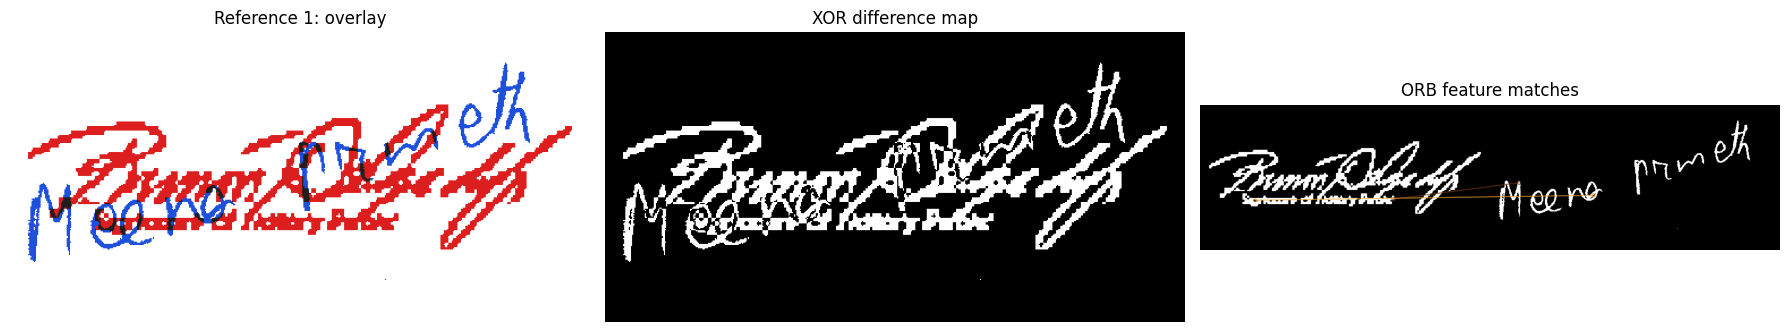

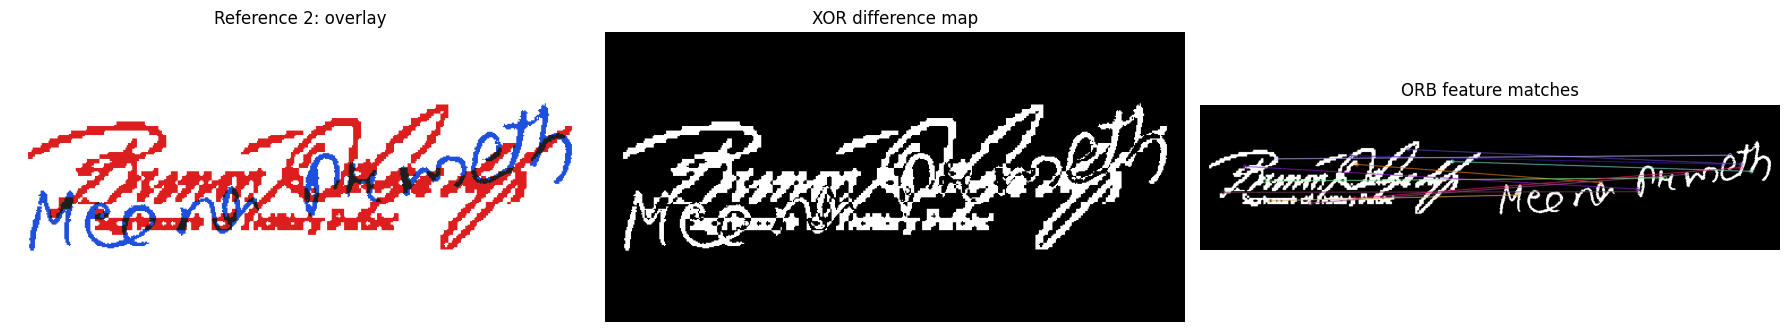

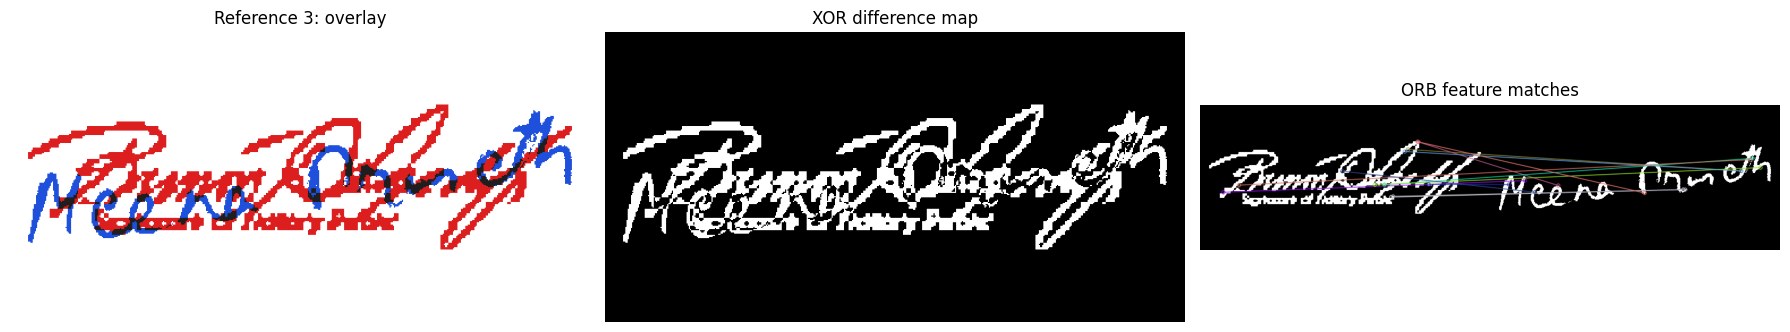

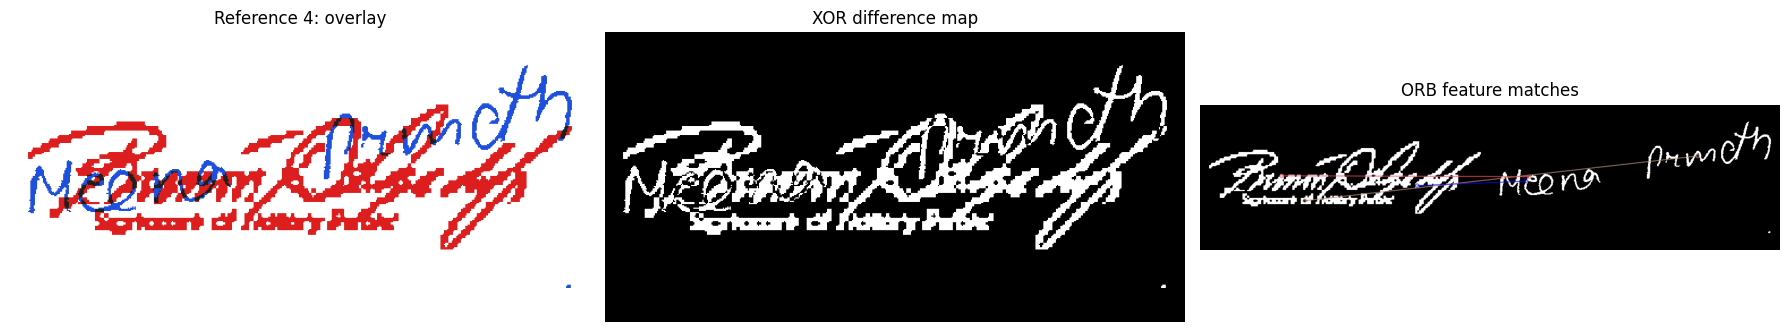

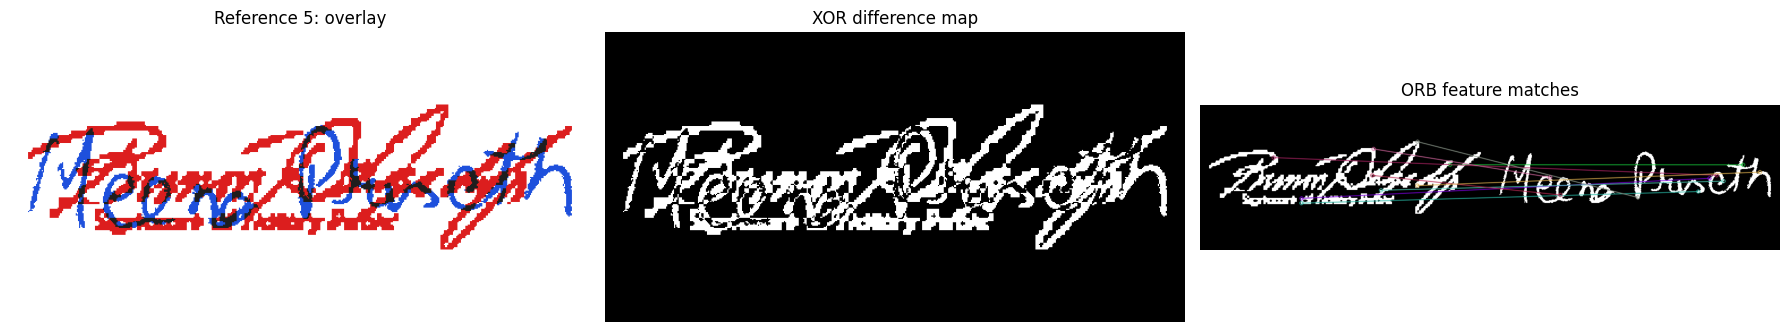

Stage 6 completed.
Report: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/forensics/structural_and_duplicate_report.json
Evidence images: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/forensics


In [122]:
# %% [markdown]
# ## Cell 59 — Visualise overlays, XOR maps, and ORB matches
#
# Overlay colours:
#
# - dark: overlapping normalized ink;
# - red: questioned-only ink;
# - blue: reference-only ink.


# %%
for visual in forensic_result["visuals"]:
    reference_number = visual["reference_index"]

    figure, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5),
    )

    axes[0].imshow(visual["overlay"])
    axes[0].set_title(
        f"Reference {reference_number}: overlay"
    )

    axes[1].imshow(
        visual["xor_map"],
        cmap="gray",
    )
    axes[1].set_title("XOR difference map")

    axes[2].imshow(visual["orb_matches"])
    axes[2].set_title("ORB feature matches")

    for axis in axes:
        axis.axis("off")

    plt.tight_layout()
    plt.show()


# %% [markdown]
# ## Cell 60 — Save Stage 6 results and evidence images


# %%
FORENSICS_OUTPUT_DIRECTORY = (
    RUN_DIRECTORY
    / "forensics"
)

FORENSICS_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

# NumPy image arrays are saved separately, so the JSON remains readable.
serializable_forensic_result = {
    key: value
    for key, value in forensic_result.items()
    if key != "visuals"
}

FORENSICS_REPORT_PATH = (
    FORENSICS_OUTPUT_DIRECTORY
    / "structural_and_duplicate_report.json"
)

FORENSICS_REPORT_PATH.write_text(
    json.dumps(
        serializable_forensic_result,
        indent=2,
    ),
    encoding="utf-8",
)

for visual in forensic_result["visuals"]:
    reference_number = visual["reference_index"]

    cv2.imwrite(
        str(
            FORENSICS_OUTPUT_DIRECTORY
            / f"reference_{reference_number:02d}_overlay.png"
        ),
        cv2.cvtColor(
            visual["overlay"],
            cv2.COLOR_RGB2BGR,
        ),
    )

    cv2.imwrite(
        str(
            FORENSICS_OUTPUT_DIRECTORY
            / f"reference_{reference_number:02d}_xor.png"
        ),
        visual["xor_map"],
    )

    cv2.imwrite(
        str(
            FORENSICS_OUTPUT_DIRECTORY
            / f"reference_{reference_number:02d}_orb.png"
        ),
        cv2.cvtColor(
            visual["orb_matches"],
            cv2.COLOR_RGB2BGR,
        ),
    )

print("Stage 6 completed.")
print("Report:", FORENSICS_REPORT_PATH)
print("Evidence images:", FORENSICS_OUTPUT_DIRECTORY)


In [123]:
# # Stage 7 — Transparent evidence fusion and quality gates
#
# This stage combines review-priority indicators using config.yaml weights.
# It does not introduce another machine-learning model, and it never returns
# "genuine" or "forged" as a decision.

In [151]:
# Cell 61 — Load risk.py directly from Google Drive

import importlib.util
import sys

RISK_MODULE_PATH = (
    PROJECT_DIRECTORY
    / "src/risk.py"
)

if not RISK_MODULE_PATH.is_file():
    raise FileNotFoundError(
        f"risk.py is missing: {RISK_MODULE_PATH}"
    )

# Use a unique module name to avoid collision with the cached `src` package.
risk_module_name = "signature_forensics_risk"

risk_spec = importlib.util.spec_from_file_location(
    risk_module_name,
    RISK_MODULE_PATH,
)

if risk_spec is None or risk_spec.loader is None:
    raise ImportError(
        "Could not load risk.py from "
        f"{RISK_MODULE_PATH}"
    )

risk_module = importlib.util.module_from_spec(
    risk_spec
)

sys.modules[risk_module_name] = risk_module

risk_spec.loader.exec_module(
    risk_module
)

# Obtain the required functions directly from the loaded module.
fuse_signature_evidence = (
    risk_module.fuse_signature_evidence
)

load_risk_config = (
    risk_module.load_risk_config
)

save_risk_result = (
    risk_module.save_risk_result
)

print(
    "Risk-fusion module imported:",
    RISK_MODULE_PATH,
)

Risk-fusion module imported: /content/drive/MyDrive/Signature-Forensic-Prototype/src/risk.py


In [153]:
# Cell 62 — Restore and load the Stage 7 fusion rules
#
# These are prototype review thresholds, not universal forensic thresholds.

import yaml

# Read the existing project configuration.
with CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as config_file:
    current_config = yaml.safe_load(
        config_file
    )

if not isinstance(current_config, dict):
    raise ValueError(
        "config.yaml does not contain a valid dictionary."
    )

# Quality gates used to decide whether the available evidence is adequate.
current_config["quality"] = {
    "minimum_overall_score": 0.60,
    "minimum_segmentation_score": 0.55,
    "minimum_cleaning_score": 0.55,
    "maximum_missing_stage_fraction": 0.25,
}

# Starting weights for the four risk components.
#
# The verification weight will be reduced automatically when the CEDAR
# external-validation result shows weak generalization.
current_config["risk_weights"] = {
    "verification": 0.45,
    "quality": 0.20,
    "forensic": 0.20,
    "duplicate": 0.15,
}

# Rules used to translate the fused review-risk score into a review category.
current_config["risk_decisions"] = {
    "provisionally_consistent_maximum": 0.30,
    "manual_review_maximum": 0.65,
    "possible_digital_reuse_minimum": 0.70,
    "insufficient_quality_maximum_quality_score": 0.45,
}

# Save the corrected configuration permanently in Google Drive.
with CONFIG_PATH.open(
    "w",
    encoding="utf-8",
) as config_file:
    yaml.safe_dump(
        current_config,
        config_file,
        sort_keys=False,
    )

# Load and validate the three required sections through risk.py.
risk_config = load_risk_config(
    CONFIG_PATH
)

print("QUALITY GATES")
print("=============")
print(
    yaml.safe_dump(
        risk_config["quality"],
        sort_keys=False,
    )
)

print("CONFIGURED RISK WEIGHTS")
print("=======================")
print(
    yaml.safe_dump(
        risk_config["risk_weights"],
        sort_keys=False,
    )
)

print("DECISION BOUNDARIES")
print("===================")
print(
    yaml.safe_dump(
        risk_config["risk_decisions"],
        sort_keys=False,
    )
)

print("Cell 62 completed successfully.")

QUALITY GATES
minimum_overall_score: 0.6
minimum_segmentation_score: 0.55
minimum_cleaning_score: 0.55
maximum_missing_stage_fraction: 0.25

CONFIGURED RISK WEIGHTS
verification: 0.45
quality: 0.2
forensic: 0.2
duplicate: 0.15

DECISION BOUNDARIES
provisionally_consistent_maximum: 0.3
manual_review_maximum: 0.65
possible_digital_reuse_minimum: 0.7
insufficient_quality_maximum_quality_score: 0.45

Cell 62 completed successfully.


In [154]:
# Cell 63 — Collect the evidence required for risk fusion
#
# This cell does not calculate risk. It verifies that all required Stage 5,
# Stage 5B and Stage 6 results are available.

import json

# Prefer the fresh-image result from Cell 48.
# If it is unavailable, use the original result from Cell 46.
stage7_verification_result = globals().get(
    "fresh_verification_result"
)

if stage7_verification_result is None:
    stage7_verification_result = globals().get(
        "verification_result"
    )

if stage7_verification_result is None:
    raise ValueError(
        "No verification result is available. "
        "Run Cell 46 or Cell 48 before Stage 7."
    )

# Ensure the verification configuration is available.
if "verification_config" not in globals():
    verification_config = load_verification_config(
        CONFIG_PATH
    )

# Load the original BHSig260 validation calibration.
calibration_path = (
    PROJECT_DIRECTORY
    / verification_config["calibration_path"]
)

if not calibration_path.is_file():
    raise FileNotFoundError(
        f"Verification calibration is missing: {calibration_path}"
    )

stage7_calibration = load_calibration(
    calibration_path
)

# Load the untouched CEDAR external-validation report.
CEDAR_REPORT_PATH = (
    PROJECT_DIRECTORY
    / "models/cedar_external_test_report.json"
)

if not CEDAR_REPORT_PATH.is_file():
    raise FileNotFoundError(
        "The CEDAR external-validation report is missing. "
        f"Expected: {CEDAR_REPORT_PATH}"
    )

with CEDAR_REPORT_PATH.open(
    "r",
    encoding="utf-8",
) as report_file:
    cedar_external_report = json.load(
        report_file
    )

# Confirm that Stage 6 results remain in memory.
if "forensic_result" not in globals():
    raise ValueError(
        "Stage 6 forensic_result is unavailable. "
        "Rerun Stage 6 Cell 57 before continuing."
    )

# Confirm the earlier pipeline outputs remain in memory.
required_variables = [
    "document_result",
    "accepted_detections",
    "segmentation_results",
    "cleaning_results",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise ValueError(
        "Required pipeline results are missing from memory: "
        f"{missing_variables}. Rerun the corresponding earlier cells."
    )

if not accepted_detections:
    raise ValueError(
        "accepted_detections is empty."
    )

if not segmentation_results:
    raise ValueError(
        "segmentation_results is empty."
    )

if not cleaning_results:
    raise ValueError(
        "cleaning_results is empty."
    )

print("CURRENT EVIDENCE IS AVAILABLE")
print("=============================")
print("- Document quality")
print("- Accepted signature detection")
print("- Segmentation quality")
print("- Cleaning quality")
print("- Siamese verification result")
print("- BHSig260 validation calibration")
print("- CEDAR external-validation report")
print("- Structural and duplicate indicators")

print()
print(
    "Verification status:",
    stage7_verification_result[
        "verification_status"
    ],
)
print(
    "Verification median:",
    stage7_verification_result[
        "median_similarity"
    ],
)
print(
    "CEDAR ROC-AUC:",
    cedar_external_report["roc_auc"],
)
print(
    "CEDAR false-acceptance rate:",
    cedar_external_report[
        "false_acceptance_rate_at_bhsig_threshold"
    ],
)

print("Cell 63 completed successfully.")

CURRENT EVIDENCE IS AVAILABLE
- Document quality
- Accepted signature detection
- Segmentation quality
- Cleaning quality
- Siamese verification result
- BHSig260 validation calibration
- CEDAR external-validation report
- Structural and duplicate indicators

Verification status: elevated_inconsistency
Verification median: 0.502923
CEDAR ROC-AUC: 0.733632
CEDAR false-acceptance rate: 0.774091
Cell 63 completed successfully.


In [155]:
# Cell 64 — Fuse the available evidence
#
# This applies transparent rules and quality gates.
# It does not determine whether the signature is genuine or forged.

risk_result = fuse_signature_evidence(
    # Stage 1: document quality
    document_quality=document_result[
        "quality"
    ],

    # Stage 2: accepted YOLO detection
    detection=accepted_detections[0],

    # Stage 3: SAM segmentation quality
    segmentation_quality=segmentation_results[0][
        "quality"
    ],

    # Stage 4: conservative cleaning quality
    cleaning_quality=cleaning_results[0][
        "quality"
    ],

    # Stage 5: Siamese comparison result
    verification_result=stage7_verification_result,

    # BHSig260 validation-derived boundaries
    calibration=stage7_calibration,

    # Stage 6: structural and duplicate evidence
    forensic_result=forensic_result,

    # Stage 5B: untouched CEDAR test results
    external_validation_report=cedar_external_report,

    # Cell 62 configuration
    risk_config=risk_config,
)

print("STAGE 7 RISK-FUSION RESULT")
print("==========================")

print(
    json.dumps(
        risk_result,
        indent=2,
    )
)

print()
print("SUMMARY")
print("=======")

print(
    "Decision:",
    risk_result["decision"],
)

print(
    "Overall review risk:",
    risk_result["overall_risk"],
)

print(
    "Verification reliability:",
    risk_result[
        "verification_reliability"
    ]["score"],
)

print(
    "Quality score:",
    risk_result[
        "quality_validation"
    ]["quality_score"],
)

print()
print(
    "Important: this is a review-priority result, "
    "not an authenticity decision."
)

STAGE 7 RISK-FUSION RESULT
{
  "component_risks": {
    "verification": 0.703663,
    "quality": 0.274932,
    "forensic": 0.40128,
    "duplicate": 0.21225
  },
  "configured_weights": {
    "verification": 0.45,
    "quality": 0.2,
    "forensic": 0.2,
    "duplicate": 0.15
  },
  "effective_weights": {
    "verification": 0.150573,
    "quality": 0.308883,
    "forensic": 0.308883,
    "duplicate": 0.231662
  },
  "verification_reliability": {
    "score": 0.216656,
    "passed": false,
    "roc_auc": 0.733632,
    "false_acceptance_rate": 0.774091,
    "false_rejection_rate": 0.048333,
    "reason": "Verification contribution was down-weighted because external generalization is weak"
  },
  "quality_validation": {
    "passed": true,
    "quality_score": 0.725068,
    "missing_stage_fraction": 0.0,
    "checks": [
      {
        "name": "document_quality",
        "passed": false,
        "score": 0.833,
        "message": "Document has one or more quality warnings"
      },
     

In [156]:
# Cell 65 — Save the Stage 7 risk-fusion result
#
# The JSON file contains component risks, configured and effective weights,
# quality checks, reasons, warnings and the review-priority decision.

RISK_RESULT_PATH = (
    RUN_DIRECTORY
    / "risk_fusion_result.json"
)

save_risk_result(
    risk_result,
    RISK_RESULT_PATH,
)

# Confirm that the file was created successfully.
if not RISK_RESULT_PATH.is_file():
    raise FileNotFoundError(
        "The risk-fusion result was not saved successfully: "
        f"{RISK_RESULT_PATH}"
    )

saved_file_size = (
    RISK_RESULT_PATH.stat().st_size
)

print("STAGE 7 COMPLETED")
print("=================")

print(
    "Decision:",
    risk_result["decision"],
)

print(
    "Overall review risk:",
    risk_result["overall_risk"],
)

print(
    "Result saved:",
    RISK_RESULT_PATH,
)

print(
    "Saved file size:",
    saved_file_size,
    "bytes",
)

print()
print("Reasons:")

for reason in risk_result["reasons"]:
    print("-", reason)

if risk_result["warnings"]:
    print()
    print("Warnings:")

    for warning in risk_result["warnings"]:
        print("-", warning)

print()
print(
    risk_result["disclaimer"]
)

STAGE 7 COMPLETED
Decision: manual_review
Overall review risk: 0.363993
Result saved: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/risk_fusion_result.json
Saved file size: 2653 bytes

Reasons:
- Available indicators require human comparison
- The Siamese score cannot support a provisional-consistency outcome because untouched CEDAR generalization was weak
- Siamese status: elevated_inconsistency

Warnings:
- Document has one or more quality warnings
- Conservative cleaning fallback preserved the original ink
- 0 of 5 references aligned
- Verification contribution was down-weighted because external generalization is weak

This is a prototype review-priority result, not a finding of authenticity, forgery, or legal validity.


In [157]:
# # Stage 8 — Reviewer-friendly evidence report
#
# A deterministic local Markdown report is always created. OpenAI assistance is
# optional and receives structured evidence only—no images by default. It is
# asked to explain evidence, never to determine authenticity.


# %% [markdown]
# ## Cell 66 — Install the optional OpenAI SDK


# %%
# In Google Colab, paste and run this line without the leading `#`:
#
%pip install -q "openai>=1.50,<3"

print(
    "The local fallback report does not require an API key."
)


The local fallback report does not require an API key.


In [158]:
# ## Cell 67 — Import `reporting.py`
#
# Copy the repository's current `src/reporting.py` into the Drive project's
# `src` directory before running this cell.


# %%
import importlib.util
import sys

REPORTING_MODULE_PATH = (
    PROJECT_DIRECTORY
    / "src/reporting.py"
)

if not REPORTING_MODULE_PATH.is_file():
    raise FileNotFoundError(
        f"reporting.py is missing: {REPORTING_MODULE_PATH}"
    )

reporting_module_name = (
    "signature_forensics_reporting"
)

reporting_spec = importlib.util.spec_from_file_location(
    reporting_module_name,
    REPORTING_MODULE_PATH,
)

if reporting_spec is None or reporting_spec.loader is None:
    raise ImportError(
        f"Could not load reporting.py from {REPORTING_MODULE_PATH}"
    )

reporting_module = importlib.util.module_from_spec(
    reporting_spec
)

sys.modules[reporting_module_name] = (
    reporting_module
)

reporting_spec.loader.exec_module(
    reporting_module
)

build_evidence_bundle = (
    reporting_module.build_evidence_bundle
)
generate_assisted_report = (
    reporting_module.generate_assisted_report
)
load_reporting_config = (
    reporting_module.load_reporting_config
)
render_local_report = (
    reporting_module.render_local_report
)
save_report_artifacts = (
    reporting_module.save_report_artifacts
)

print(
    "Reporting module imported:",
    REPORTING_MODULE_PATH,
)

Reporting module imported: /content/drive/MyDrive/Signature-Forensic-Prototype/src/reporting.py


In [160]:
# ## Cell 68 — Build a minimally identifying evidence bundle
#
# Image arrays and the full source path are excluded. The bundle contains only
# structured measurements needed to explain the current result.


# %%
# Restore only the reporting section if an earlier notebook edit removed it.
with CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as config_file:
    current_config = yaml.safe_load(
        config_file
    )

if not isinstance(current_config, dict):
    raise ValueError(
        "config.yaml does not contain a valid dictionary."
    )

if not isinstance(
    current_config.get("reporting"),
    dict,
):
    current_config["reporting"] = {
        "openai_model": "gpt-4.1-mini",
        "use_low_resolution_images": False,
        "maximum_image_dimension": 768,
        "api_key_environment_variable": "OPENAI_API_KEY",
        "fallback_template_when_unavailable": True,
    }

    with CONFIG_PATH.open(
        "w",
        encoding="utf-8",
    ) as config_file:
        yaml.safe_dump(
            current_config,
            config_file,
            sort_keys=False,
        )

    print(
        "Missing reporting section restored in config.yaml."
    )

reporting_config = load_reporting_config(
    CONFIG_PATH
)

report_evidence = build_evidence_bundle(
    case_id=RUN_DIRECTORY.name,
    document_quality=document_result[
        "quality"
    ],
    detection=accepted_detections[0],
    segmentation_quality=segmentation_results[0][
        "quality"
    ],
    cleaning_quality=cleaning_results[0][
        "quality"
    ],
    verification_result=stage7_verification_result,
    external_validation_report=cedar_external_report,
    forensic_result=forensic_result,
    risk_result=risk_result,
)

print("Evidence sections:")
for section_name in report_evidence:
    print("-", section_name)

print(
    "Images included:",
    report_evidence["reporting_scope"][
        "images_included"
    ],
)

Missing reporting section restored in config.yaml.
Evidence sections:
- case_id
- document_quality
- detection
- segmentation_quality
- cleaning_quality
- verification
- external_validation
- forensic_indicators
- risk_result
- reporting_scope
Images included: False


In [161]:
# ## Cell 69 — Generate and display the safe local report
#
# Run this cell even when you plan to use OpenAI assistance. It guarantees that
# a complete deterministic report is available if the API is unavailable.


# %%
from IPython.display import Markdown, display

local_report_markdown = render_local_report(
    report_evidence
)

display(
    Markdown(local_report_markdown)
)

# Signature Analysis Review Report

## 1. Case summary

- Case ID: `20260727T153721_774776Z`
- Review-priority category: `manual_review`
- Overall review-risk score: `0.363993`
- This score is not a probability that the signature is genuine or forged.

## 2. Input-quality assessment

- Pipeline quality score: `0.725068`
- Document quality passed: `False`
- Cleaning fallback used: `True`

Warnings:

- Document has one or more quality warnings
- Conservative cleaning fallback preserved the original ink
- 0 of 5 references aligned
- Verification contribution was down-weighted because external generalization is weak

## 3. Signature-detection result

- Detected class: `signature`
- Detector confidence: `0.717405`
- Bounding box: `[237, 308, 373, 348]`
- Detection quality passed: `True`

## 4. Segmentation and cleaning assessment

- Segmentation passed: `True`
- Segmentation quality score: `1.0`
- Cleaning passed: `False`
- Cleaning quality score: `1.0`
- Cleaning fallback used: `True`

## 5. Verification observations

- Status: `elevated_inconsistency`
- Mean similarity: `0.498783`
- Median similarity: `0.502923`
- Similarity spread: `0.177457`
- External CEDAR ROC-AUC: `0.733632`
- External CEDAR false-acceptance rate: `0.774091`
- Verification reliability score used in fusion: `0.216656`

The Siamese result was down-weighted because untouched CEDAR testing showed
weak cross-dataset generalization.

## 6. Structural observations

- Successful reference alignments: `0` of `5`
- Questioned structural measurements are preserved in the accompanying JSON.
- Failed ORB/RANSAC alignment means alignment-dependent comparisons are
  inconclusive; it does not itself indicate inconsistency.

## 7. Duplicate and reuse observations

No reference met the configured multi-method reuse warning.

Embedding similarity alone was not used as evidence of digital copying.

## 8. Overall recommendation

Decision reasons:

- Available indicators require human comparison
- The Siamese score cannot support a provisional-consistency outcome because untouched CEDAR generalization was weak
- Siamese status: elevated_inconsistency

The recorded outcome is a review-priority category. A qualified human reviewer
should inspect the original document, original crop, segmentation, cleaning,
reference specimens, overlays, and source provenance.

## 9. Limitations

- The verification network showed weak untouched CEDAR generalization.
- Automated cleaning used a conservative fallback.
- ORB/RANSAC may fail on thin, low-texture signature strokes.
- Thresholds and risk weights are prototype settings rather than universally
  validated forensic criteria.
- Image-based analysis cannot establish signing intent, authorization, timing,
  custody, or legal validity.

## 10. Human-review disclaimer

This educational prototype does not determine whether a signature is genuine
or forged. Its outputs must not be used as the sole basis for legal, financial,
employment, identity, or access-control decisions.


In [163]:
# ## Cell 70 — Optionally request an OpenAI-assisted explanation
#
# Leave `USE_OPENAI_ASSISTANCE = False` for the local report. Set it to `True`
# only when you choose to send the structured evidence to the configured model.
# The API call can incur charges. The key is entered privately and is not saved
# in the notebook or report.


# %%
import getpass
import os

USE_OPENAI_ASSISTANCE = True

api_key_variable = reporting_config.get(
    "api_key_environment_variable",
    "OPENAI_API_KEY",
)

if (
    USE_OPENAI_ASSISTANCE
    and not os.getenv(api_key_variable)
):
    os.environ[api_key_variable] = (
        getpass.getpass(
            f"Enter {api_key_variable}: "
        )
    )

report_result = generate_assisted_report(
    evidence=report_evidence,
    reporting_config=reporting_config,
    use_openai=USE_OPENAI_ASSISTANCE,
)

print(
    "OpenAI assistance used:",
    report_result["used_openai"],
)

if report_result["fallback_reason"]:
    print(
        "Fallback reason:",
        report_result["fallback_reason"],
    )

display(
    Markdown(
        report_result["report_markdown"]
    )
)


Enter OPENAI_API_KEY: ··········
OpenAI assistance used: True


# Case summary
Case ID: 20260727T153721_774776Z  
Purpose: Review-priority evidence summary related to a questioned signature on the submitted document. The report does not provide any determination concerning the authenticity, forgery, or legal validity of the signature or document.

# Input-quality assessment
- Overall document quality did not pass (score: 0.833), with the primary issue being:
  - Page resolution below the recommended 600 × 600 pixels (actual: 393 × 508 pixels).
- Other quality checks passed including page dimensions, brightness levels, blur/sharpness, and skew.
- Document quality warnings:
  - Page resolution is below 600 × 600 pixels.

# Signature-detection result
- Signature detected with confidence of 0.717.
- Bounding box coordinates: (237, 308) to (373, 348).
- Detection quality passed with area ratio of 0.0272; signature does not touch image boundaries and no warnings.

# Segmentation and cleaning assessment
- Segmentation quality passed with a perfect quality score of 1.0 and an intersection-over-union (IOU) of 0.909.
- Mask covers 41.6% of the detection box area.
- Minor boundary touching on one side.
- Cleaning quality did not pass:
  - Quality score 1.0 but a conservative fallback was used because proposed cleaning would have removed 40.9% of foreground ink, exceeding the 35.0% limit.
  - No foreground removal occurred; original ink components and endpoints were preserved.
  - Warning: Conservative cleaning fallback preserved the original ink to avoid losing too much data.

# Verification observations
- Five reference comparisons showed elevated inconsistency:
  - Mean similarity: 0.4988 (range 0.4212 to 0.5987).
  - Score spread: 0.1775.
  - No reference alignment succeeded; zero out of five reference signatures aligned reliably.
- Verification status: elevated_inconsistency.
- Verification reliability score is low at 0.217.
- External validation showed weak generalization on the CEDAR dataset:
  - ROC AUC: 0.734.
  - Accuracy at BHSig260 threshold: 58.9%.
  - False acceptance rate high at 77.4%, false rejection low at 4.8%.
- Consequently, verification contribution was down-weighted due to weak external generalization, limiting the strength of Siamese network evidence.
- Five reference comparisons available, but none could be aligned or matched successfully.

# Forensic observations
- Questioned signature characteristics:
  - Aspect ratio: 3.75.
  - Foreground (ink) ratio: 0.113.
  - Connected components: 5.
  - Contour count: 5.
  - Bounding box occupancy: 0.241.
  - Skeleton length: 2356 units.
  - Skeleton endpoints: 54.
  - Skeleton branch points: 334.
  - Slant angle: -0.66°.
  - Centroid near image center.
  - Hu moments (log scale) provided for shape analysis.
- Compared to multiple references, structural differences were substantial, with mean relative difference around 38% to 56% across features.
- No reliable alignment could be established from keypoints or geometric matching.
- No indications of exact or possible duplicates from forensic evidence.
- Forensic quality did not pass due to failure to align any references.
- Line overlap assessment limited by cleaning fallback; no line overlap detected or removed.

# Duplicate-detection observations
- Duplicate detection across references showed no exact normalized duplicates or possible duplicates were found.
- Perceptual hash distances from 20 to 30 indicate no high similarity.
- Low ORB good match counts and no RANSAC inliers reinforce that no duplicates were detected.
- Duplicate detection quality passed with low risk.

# Overall recommendation
- Risk result: 0.364 (moderate risk).
- Decision: manual_review recommended.
- Reasons:
  - Available indicators require human expert comparison.
  - Siamese network similarity scores cannot support a provisional consistency finding due to weak generalization on the untouched CEDAR external test dataset.
  - Verification status shows elevated inconsistency.
- Multiple warnings advise caution:
  - Document quality not fully optimal.
  - Conservative cleaning fallback limits cleaning assessment.
  - No references successfully aligned.
  - Verification contribution was down-weighted because of weak external generalization.

# Limitations
- Document resolution is below ideal standards, potentially impacting detection and analysis.
- Cleaning fallback preserved all original ink due to risk of excessive ink removal, limiting cleaning quality insights.
- No successful alignment with reference signatures limits confidence in verification and forensic comparative findings.
- External validation highlights weak generalization of the Siamese signature verification model on the CEDAR dataset, reducing the reliability of verification evidence.
- Analysis does not provide a conclusive authenticity or forgery determination.

# Human-review disclaimer
This report presents a prototype review-priority evidence summary and is not an opinion on the authenticity, forgery, or legal validity of the questioned signature or document. Human expert examination and comparison are necessary for any conclusive findings.

In [164]:
# ## Cell 71 — Save report artifacts permanently


# %%
REPORT_OUTPUT_DIRECTORY = (
    RUN_DIRECTORY
    / "report"
)

saved_report_paths = save_report_artifacts(
    evidence=report_evidence,
    report_result=report_result,
    output_directory=REPORT_OUTPUT_DIRECTORY,
)

print("STAGE 8 COMPLETED")
print("=================")

for artifact_name, artifact_path in (
    saved_report_paths.items()
):
    print(
        f"{artifact_name}:",
        artifact_path,
    )

print(
    "OpenAI assistance used:",
    report_result["used_openai"],
)

STAGE 8 COMPLETED
evidence_path: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/report/report_evidence.json
report_path: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/report/review_report.md
metadata_path: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/report/report_generation_metadata.json
OpenAI assistance used: True
